<a href="https://colab.research.google.com/github/GIVEN-CHINYAMA/usd-zmw-exchange-rate-forecasting/blob/main/usd_zmw_exchange_rate_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Forecasting the USD/ZMW Exchange Rate Using ARIMA and LSTM Models

---

> **Author:** Given Chinyama

> **Institution:** Kwame Nkrumah University

> **Date:** May,2026


## 📋 Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | [Project Overview](#overview) | Background, motivation, and scope |
| 2 | [Research Objectives](#objectives) | What this project aims to achieve |
| 3 | [Dataset Description](#dataset) | Source, variables, and coverage |
| 4 | [Methodology Summary](#methodology) | ARIMA + LSTM approach |
| 5 | [Stage 1 — Environment Setup](#stage1) | Install libraries and import packages |
| 6 | [Stage 2 — Data Collection](#stage2) | Download and load USD/ZMW data |
| 7 | [Stage 3 — Preprocessing & EDA](#stage3) | Clean, visualise, and test stationarity |
| 8 | [Stage 4 — ARIMA Modelling](#stage4) | Build and evaluate ARIMA model |
| 9 | [Stage 5 — LSTM Modelling](#stage5) | Build and train deep learning model |
| 10 | [Stage 6 — Evaluation & Comparison](#stage6) | RMSE, MAE, MAPE comparison |
| 11 | [Stage 7 — 30-Day Forecast](#stage7) | Future exchange rate forecast |
| 12 | [Conclusion](#conclusion) | Summary, limitations, future work |

---
<a name="overview"></a>

## 1. 📌 Project Overview

### Background

The Zambian Kwacha (ZMW) has experienced significant fluctuations against the US Dollar (USD) over the past decade, driven by a range of macroeconomic forces including copper price volatility, inflation, external debt levels, COVID-19 economic disruptions, and shifts in foreign direct investment. Accurate forecasting of the USD/ZMW exchange rate is of critical importance to importers, exporters, policymakers at the Bank of Zambia, businesses engaged in cross-border trade, and individual investors managing currency risk.

Exchange rate forecasting remains one of the most challenging problems in financial econometrics. Traditional statistical methods such as **ARIMA** (AutoRegressive Integrated Moving Average) have long been applied to time series data and remain widely used due to their interpretability and strong theoretical foundation. However, they assume linear relationships and may struggle to capture complex non-linear dynamics.

In contrast, **Long Short-Term Memory (LSTM)** networks — a specialised class of Recurrent Neural Networks (RNNs) — have emerged as a powerful tool for modelling sequential, non-linear time series data. LSTMs are capable of learning long-range dependencies in data without requiring the stationarity assumptions that constrain ARIMA models.

### Motivation

This project is motivated by three key questions:

1. Can classical time series models (ARIMA) adequately forecast the USD/ZMW exchange rate?
2. Do deep learning models (LSTM) offer a meaningful improvement in forecast accuracy?
3. Which model is better suited for practical deployment in the Zambian financial context?

---

<a name="objectives"></a>

## 2. 🎯 Research Objectives

The specific objectives of this project are:

1. **To collect and preprocess** daily USD/ZMW exchange rate data spanning at least 9 years (2015–2024).
2. **To conduct Exploratory Data Analysis (EDA)** including trend analysis, seasonality detection, and statistical stationarity testing using the Augmented Dickey-Fuller (ADF) test.
3. **To build and optimise an ARIMA model** by identifying the appropriate order (p, d, q) through ACF/PACF analysis and automated selection via AIC/BIC criteria.
4. **To build and train an LSTM neural network** with appropriate architecture (layers, dropout, lookback window) for sequential forecasting.
5. **To evaluate and compare both models** using standard forecast accuracy metrics: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and Mean Absolute Percentage Error (MAPE).
6. **To generate a 30-day ahead forecast** of the USD/ZMW rate from the most recent data point.
7. **To draw conclusions** about the relative strengths and limitations of each approach in the context of an emerging market currency.

### Scope

| Item | Detail |
|------|--------|
| **Currency pair** | USD/ZMW (US Dollar to Zambian Kwacha) |
| **Data period** | January 2015 – December 2024 |
| **Data frequency** | Daily (business days) |
| **Forecast horizon** | 30 days ahead |
| **Models compared** | ARIMA and LSTM |
| **Platform** | Google Colab (Python 3.10+) |

---

<a name="dataset"></a>

## 3. 📂 Dataset Description

### Source Options

This project uses the **daily USD/ZMW mid-market exchange rate**. The data can be obtained from any of the following sources:

| Source | Access Method | Link | Notes |
|--------|--------------|------|-------|
| **Yahoo Finance** | `yfinance` Python library (ticker: `ZMW=X`) | [finance.yahoo.com](https://finance.yahoo.com) | Easiest; may have gaps |
| **Macrotrends** | Manual CSV download | [macrotrends.net](https://www.macrotrends.net/2550/zambian-kwacha-us-dollar-exchange-rate-historical-chart) | Most complete; recommended |
| **World Bank** | `pandas-datareader` API (indicator: `PA.NUS.FCRF`) | [data.worldbank.org](https://data.worldbank.org) | Annual only; less useful |
| **FRED (St. Louis Fed)** | Manual or `pandas-datareader` | [fred.stlouisfed.org](https://fred.stlouisfed.org) | Reliable; good coverage |
| **Stooq** | Manual CSV download (ticker: `USDZMW`) | [stooq.com](https://stooq.com) | Daily data; reliable |

### Variable Description

| Variable | Type | Description |
|----------|------|-------------|
| `Date` | Index (DatetimeIndex) | Business day date |
| `USDZMW` | Float | Number of Zambian Kwacha per 1 US Dollar |

### Key Characteristics

- **Non-stationary**: The series exhibits a clear upward trend (ZMW has depreciated significantly against USD since 2015)
- **Structural breaks**: Notable breaks around 2020 (COVID-19) and 2022 (global inflation)
- **Volatility clustering**: Periods of high volatility tend to cluster together
- **No strong seasonality**: Annual seasonal patterns are weak but present

---

<a name="methodology"></a>

## 4. 🔬 Methodology Summary

This project adopts a **quantitative, comparative forecasting approach** using two distinct modelling paradigms.

### ARIMA (AutoRegressive Integrated Moving Average)

ARIMA is a classical statistical model for time series forecasting. It is defined by three parameters:
- **p** — order of the autoregressive (AR) component
- **d** — degree of differencing required to achieve stationarity
- **q** — order of the moving average (MA) component

The general ARIMA(p,d,q) model is expressed as:

$$\phi(B)(1-B)^d y_t = \theta(B)\varepsilon_t$$

where $B$ is the backshift operator, $\phi(B)$ is the AR polynomial, $\theta(B)$ is the MA polynomial, and $\varepsilon_t$ is white noise.

### LSTM (Long Short-Term Memory)

LSTM is a type of Recurrent Neural Network designed to learn long-term dependencies in sequential data. It addresses the vanishing gradient problem of standard RNNs through a gating mechanism:

- **Forget gate**: decides what information to discard from cell state
- **Input gate**: decides what new information to store
- **Output gate**: decides what to output based on cell state

### Comparison Framework

Both models are trained on **80% of the data** and tested on the remaining **20%**, using a walk-forward validation approach. Performance is assessed using RMSE, MAE, and MAPE.

---
<a name="stage1"></a>

## ⚙️ Stage 1 — Environment Setup

This section installs all required Python libraries and imports them into the working environment. Run these cells once at the start of every Colab session (libraries reset when the runtime disconnects).

**Libraries used:**

| Library | Purpose |
|---------|---------|
| `yfinance` | Download financial data from Yahoo Finance |
| `pandas` | Data manipulation and time series handling |
| `numpy` | Numerical operations |
| `matplotlib` / `seaborn` | Data visualisation |
| `statsmodels` | ARIMA modelling, ACF/PACF, ADF test |
| `pmdarima` | Automatic ARIMA order selection (auto_arima) |
| `scikit-learn` | MinMaxScaler, evaluation metrics |
| `tensorflow` / `keras` | LSTM neural network |

---

In [ ]:
# ============================================================
# CODE CELL 1.1 — Install Required Libraries
# Run this once per Colab session
# ============================================================

!pip install yfinance pandas numpy matplotlib seaborn \
             statsmodels pmdarima scikit-learn \
             tensorflow pandas-datareader --quiet

print("✅ All libraries installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 24.3 MB/s eta 0:00:00
✅ All libraries installed successfully.


In [ ]:
# ============================================================
# CODE CELL 1.2 — Import All Libraries
# ============================================================

# --- Data handling ---
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_datareader.data as web
from google.colab import files
import io
import os

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# --- Statistical modelling (ARIMA) ---
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima

# --- Machine learning utilities ---
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- Deep learning (LSTM) ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- Utilities ---
import warnings
warnings.filterwarnings('ignore')

# --- Global plot style ---
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'legend.fontsize' : 10,
    'font.family'     : 'DejaVu Sans'
})
sns.set_style("darkgrid")

# --- Reproducibility ---
import random
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# --- Confirm versions ---
print("=" * 50)
print("  ENVIRONMENT READY")
print("=" * 50)
print(f"  Python      : {__import__('sys').version.split()[0]}")
print(f"  Pandas      : {pd.__version__}")
print(f"  NumPy       : {np.__version__}")
print(f"  TensorFlow  : {tf.__version__}")
print(f"  Statsmodels : {__import__('statsmodels').__version__}")
print("=" * 50)
print("✅ All imports successful. Ready to proceed.")

  ENVIRONMENT READY
  Python      : 3.12.13
  Pandas      : 2.2.2
  NumPy       : 2.0.2
  TensorFlow  : 2.20.0
  Statsmodels : 0.14.6
✅ All imports successful. Ready to proceed.


---
<a name="stage2"></a>

## 📥 Stage 2 — Data Collection

We download the daily **USD/ZMW exchange rate** using Yahoo Finance's `ZMW=X` ticker. If this returns no data (Yahoo Finance can be unreliable for exotic currency pairs), we provide two fallback options:

- **Option B** — Manual CSV upload from Macrotrends or Stooq
- **Option C** — World Bank API (annual data only, not recommended for this project)

**Always run Option A first.** Only proceed to the fallback if the output shows 0 rows.

In [ ]:
# ============================================================
# CODE CELL 2.1 — Option A: Download from Yahoo Finance
# Ticker: ZMW=X  |  Period: 2015-01-01 to 2024-12-31
# ============================================================

TICKER     = "ZMW=X"
START_DATE = "2015-01-01"
END_DATE   = "2024-12-31"

print(f"Downloading {TICKER} from Yahoo Finance...")
raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)

if raw.empty or len(raw) < 100:
    print("⚠️  Yahoo Finance returned insufficient data.")
    print("    → Please proceed to CODE CELL 2.2 (Option B — CSV Upload).")
    df = None
else:
    # Keep only the closing price and rename
    df = raw[['Close']].copy()
    df.columns = ['USDZMW']
    df.index   = pd.to_datetime(df.index)
    df.index.name = 'Date'

    print(f"✅ Data downloaded successfully.")
    print(f"   Rows         : {len(df):,}")
    print(f"   Date range   : {df.index.min().date()} → {df.index.max().date()}")
    print(f"   Min rate     : {df['USDZMW'].min():.4f} ZMW/USD")
    print(f"   Max rate     : {df['USDZMW'].max():.4f} ZMW/USD")
    print(f"   Missing vals : {df['USDZMW'].isna().sum()}")
    print()
    df.head(10)

✅ Data downloaded successfully.
   Rows         : 2,605
   Date range   : 2015-01-01 → 2024-12-30
   Min rate     : 6.3243 ZMW/USD
   Max rate     : 27.7102 ZMW/USD
   Missing vals : 0



In [ ]:
# ============================================================
# CODE CELL 2.2 — Option B: Upload CSV Manually (Fallback)
#
# ONLY run this cell if Option A returned insufficient data.
#
# HOW TO GET THE CSV:
#   1. Go to https://stooq.com/q/d/?s=usdzmw
#      OR https://www.macrotrends.net/2550/zambian-kwacha-us-dollar-exchange-rate-historical-chart
#   2. Download the historical data as a CSV file
#   3. Run this cell and upload the file when prompted
#
# EXPECTED CSV FORMAT:
#   The CSV must have at least two columns: a date column and a price/rate column.
#   Common formats:
#     Stooq:       Date, Open, High, Low, Close, Volume
#     Macrotrends: date, value
# ============================================================

if df is not None and len(df) >= 100:
    print("ℹ️  Option A data is already loaded. Skipping Option B.")
else:
    print("📁 Please upload your USD/ZMW CSV file...")
    uploaded = files.upload()

    fname = list(uploaded.keys())[0]
    raw_csv = pd.read_csv(io.BytesIO(uploaded[fname]))

    print(f"\nFile '{fname}' uploaded.")
    print(f"Columns detected: {list(raw_csv.columns)}")
    print(raw_csv.head())

    # --- Auto-detect date and price columns ---
    date_col  = [c for c in raw_csv.columns if 'date' in c.lower()][0]
    price_col = [c for c in raw_csv.columns if any(k in c.lower() for k in ['close','value','price','rate'])][0]

    print(f"\nUsing date column  : '{date_col}'")
    print(f"Using price column : '{price_col}'")

    df = raw_csv[[date_col, price_col]].copy()
    df.columns = ['Date', 'USDZMW']
    df['Date']    = pd.to_datetime(df['Date'])
    df['USDZMW']  = pd.to_numeric(df['USDZMW'], errors='coerce')
    df = df.dropna().sort_values('Date').set_index('Date')

    # Filter to project date range
    df = df.loc['2015-01-01':'2024-12-31']

    print(f"\n✅ CSV loaded and cleaned.")
    print(f"   Rows         : {len(df):,}")
    print(f"   Date range   : {df.index.min().date()} → {df.index.max().date()}")
    print(f"   Min rate     : {df['USDZMW'].min():.4f} ZMW/USD")
    print(f"   Max rate     : {df['USDZMW'].max():.4f} ZMW/USD")
    df.head(10)

ℹ️  Option A data is already loaded. Skipping Option B.


In [ ]:
# ============================================================
# CODE CELL 2.3 — Validate Data & Standardise Frequency
# ============================================================

assert df is not None, "❌ No data loaded. Run Option A or Option B first."
assert 'USDZMW' in df.columns, "❌ Column 'USDZMW' not found."

# Standardise to business-day frequency and forward-fill gaps
df = df.asfreq('B')
df['USDZMW'] = df['USDZMW'].ffill()

# Final validation report
n_missing = df['USDZMW'].isna().sum()
print("=" * 50)
print("  DATA VALIDATION REPORT")
print("=" * 50)
print(f"  Total observations : {len(df):,}")
print(f"  Start date         : {df.index.min().date()}")
print(f"  End date           : {df.index.max().date()}")
print(f"  Frequency          : Business days")
print(f"  Missing values     : {n_missing}")
print(f"  Min USD/ZMW        : {df['USDZMW'].min():.4f}")
print(f"  Max USD/ZMW        : {df['USDZMW'].max():.4f}")
print(f"  Mean USD/ZMW       : {df['USDZMW'].mean():.4f}")
print(f"  Std deviation      : {df['USDZMW'].std():.4f}")
print("=" * 50)

if n_missing == 0:
    print("✅ Data is clean and ready for analysis.")
else:
    print(f"⚠️  {n_missing} missing values remain after forward-fill. Check your data source.")

df.tail(5)

  DATA VALIDATION REPORT
  Total observations : 2,608
  Start date         : 2015-01-01
  End date           : 2024-12-30
  Frequency          : Business days
  Missing values     : 0
  Min USD/ZMW        : 6.3243
  Max USD/ZMW        : 27.7102
  Mean USD/ZMW       : 15.2844
  Std deviation      : 5.7255
✅ Data is clean and ready for analysis.


,USDZMW
Date,
2024-12-24,27.658836
2024-12-25,27.610674
2024-12-26,27.610674
2024-12-27,27.582960
2024-12-30,27.710161


In [ ]:
# ============================================================
# CODE CELL 2.4 — Save Raw Data as Checkpoint
# This creates a local copy in the Colab environment
# and lets you download it for version control (GitHub)
# ============================================================

os.makedirs('outputs', exist_ok=True)

df.to_csv('outputs/usdzmw_raw.csv')
print("✅ Raw data saved to: outputs/usdzmw_raw.csv")
print(f"   Shape: {df.shape}")
print()

# Quick preview of first and last 3 rows
print("First 3 rows:")
print(df.head(3).to_string())
print("\nLast 3 rows:")
print(df.tail(3).to_string())

✅ Raw data saved to: outputs/usdzmw_raw.csv
   Shape: (2608, 1)

First 3 rows:
            USDZMW
Date              
2015-01-01  6.3597
2015-01-02  6.3888
2015-01-05  6.3482

Last 3 rows:
               USDZMW
Date                 
2024-12-26  27.610674
2024-12-27  27.582960
2024-12-30  27.710161


---
<a name="stage3"></a>

## Stage 3 - Preprocessing and Exploratory Data Analysis (EDA)

Before modelling, we must understand the structure of the data. This stage covers:

1. Checking and handling missing values
2. Visualising the raw time series, trend, and rolling statistics
3. Log-transformation to stabilise variance
4. Seasonal decomposition
5. Stationarity testing using the Augmented Dickey-Fuller (ADF) test
6. Train/test split (80% train, 20% test)

---

In [ ]:
# ============================================================
# CODE CELL 3.1 - Check Missing Values & Apply Log Transform
# ============================================================

print("=" * 50)
print("  DATA QUALITY CHECK")
print("=" * 50)
print(f"  Total rows       : {len(df):,}")
print(f"  Missing values   : {df['USDZMW'].isna().sum()}")
print(f"  Duplicate dates  : {df.index.duplicated().sum()}")
print(f"  Start            : {df.index.min().date()}")
print(f"  End              : {df.index.max().date()}")
print("=" * 50)

# Add log-transformed column (stabilises exponential growth)
df['log_USDZMW'] = np.log(df['USDZMW'])

# Add first-difference of log (returns / percentage changes)
df['diff_log'] = df['log_USDZMW'].diff()

print("\n✅ New columns added:")
print(df[['USDZMW','log_USDZMW','diff_log']].tail(5))

  DATA QUALITY CHECK
  Total rows       : 2,608
  Missing values   : 0
  Duplicate dates  : 0
  Start            : 2015-01-01
  End              : 2024-12-30

✅ New columns added:
               USDZMW  log_USDZMW  diff_log
Date                                       
2024-12-24  27.658836    3.319945  0.005171
2024-12-25  27.610674    3.318202 -0.001743
2024-12-26  27.610674    3.318202  0.000000
2024-12-27  27.582960    3.317198 -0.001004
2024-12-30  27.710161    3.321799  0.004601


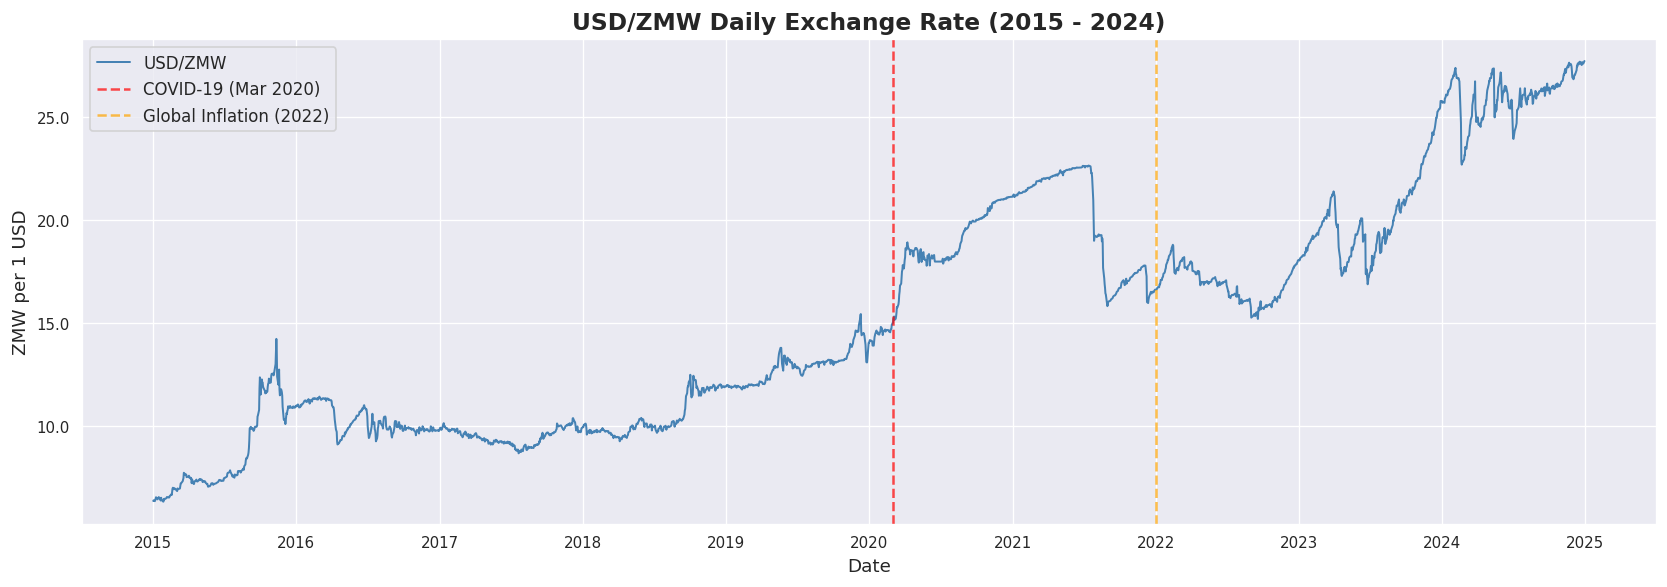

✅ Plot saved: outputs/01_raw_series.png


In [ ]:
# ============================================================
# CODE CELL 3.2 - Plot Raw USD/ZMW Time Series
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['USDZMW'], color='steelblue', linewidth=1.2, label='USD/ZMW')
ax.axvline(pd.Timestamp('2020-03-01'), color='red',    linestyle='--', alpha=0.7, label='COVID-19 (Mar 2020)')
ax.axvline(pd.Timestamp('2022-01-01'), color='orange', linestyle='--', alpha=0.7, label='Global Inflation (2022)')

ax.set_title('USD/ZMW Daily Exchange Rate (2015 - 2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('ZMW per 1 USD')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))

plt.tight_layout()
plt.savefig('outputs/01_raw_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: outputs/01_raw_series.png")

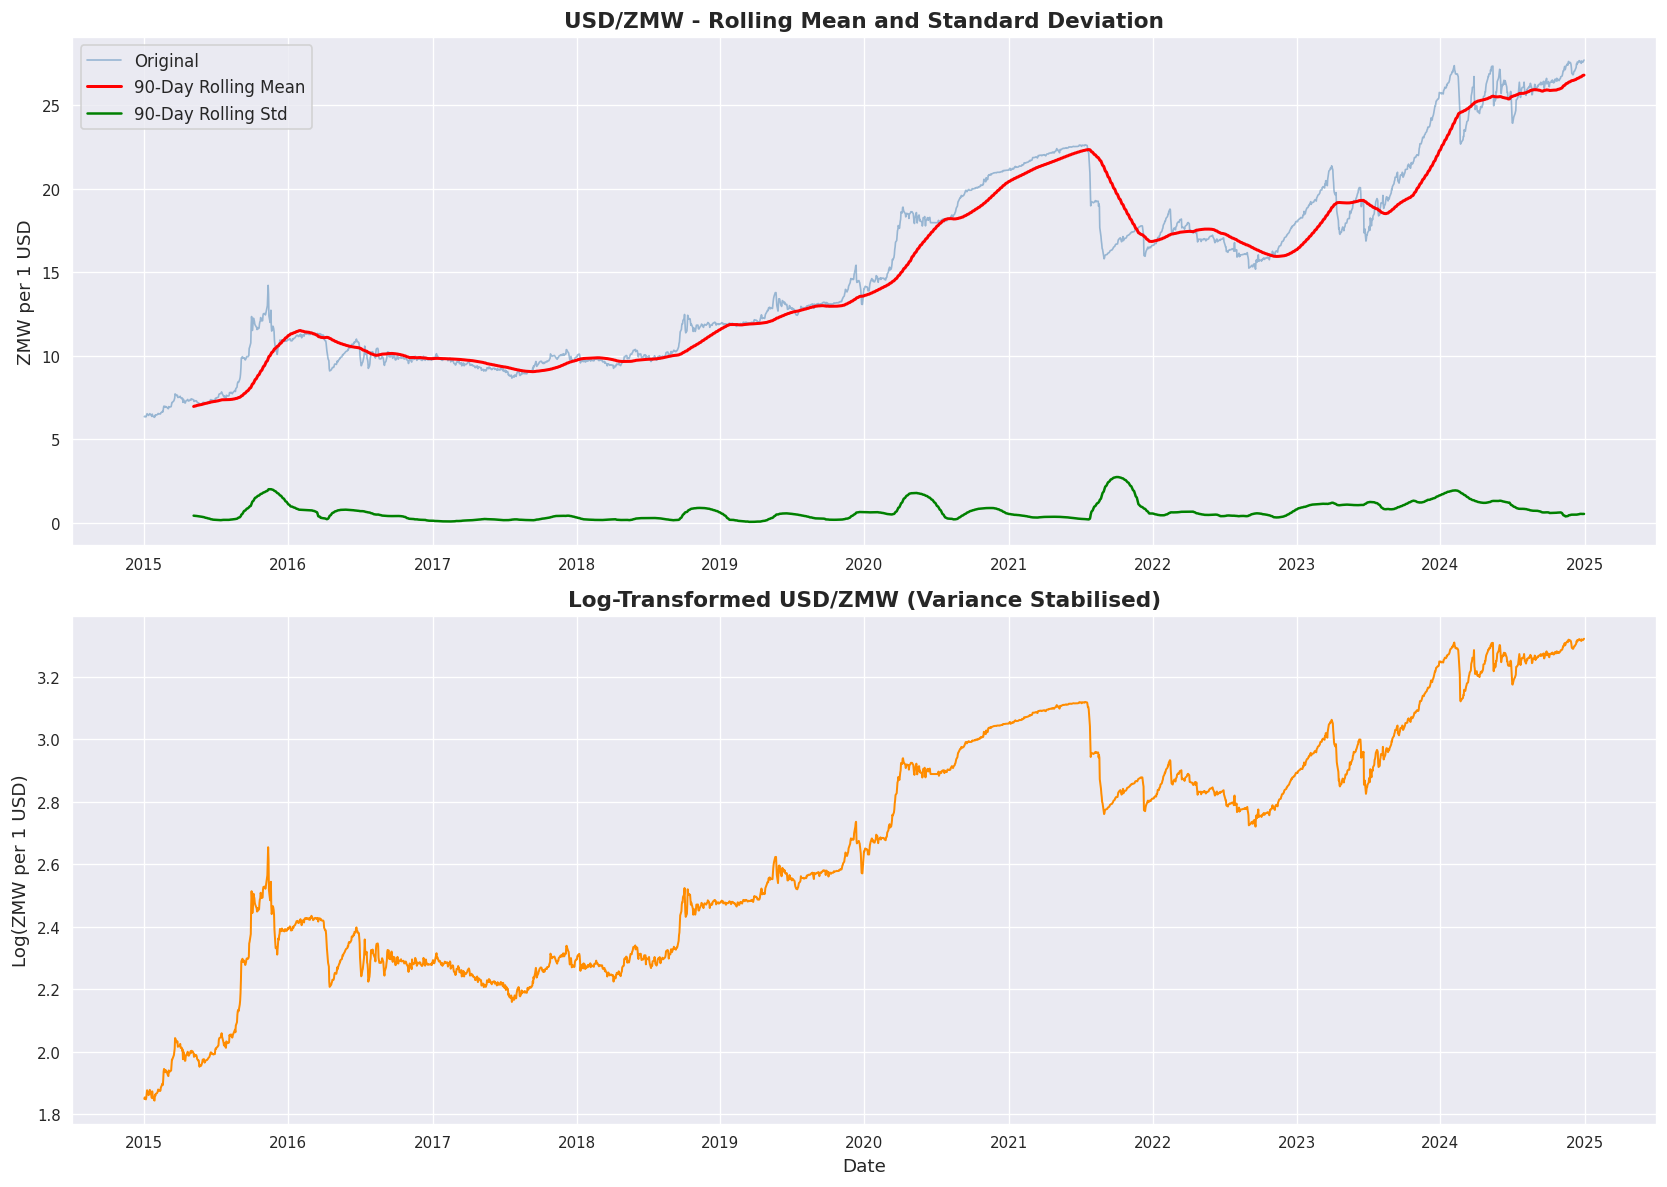

✅ Plot saved: outputs/02_rolling_stats.png


In [ ]:
# ============================================================
# CODE CELL 3.3 - Rolling Statistics and Log Transform
# ============================================================

rolling_mean = df['USDZMW'].rolling(window=90).mean()
rolling_std  = df['USDZMW'].rolling(window=90).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Top: Rolling mean & std ---
axes[0].plot(df['USDZMW'],  color='steelblue', alpha=0.5, label='Original', linewidth=1)
axes[0].plot(rolling_mean,  color='red',       linewidth=1.8, label='90-Day Rolling Mean')
axes[0].plot(rolling_std,   color='green',     linewidth=1.5, label='90-Day Rolling Std')
axes[0].set_title('USD/ZMW - Rolling Mean and Standard Deviation', fontweight='bold')
axes[0].set_ylabel('ZMW per 1 USD')
axes[0].legend()

# --- Bottom: Log-transformed ---
axes[1].plot(df.index, df['log_USDZMW'], color='darkorange', linewidth=1.2)
axes[1].set_title('Log-Transformed USD/ZMW (Variance Stabilised)', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Log(ZMW per 1 USD)')

plt.tight_layout()
plt.savefig('outputs/02_rolling_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: outputs/02_rolling_stats.png")

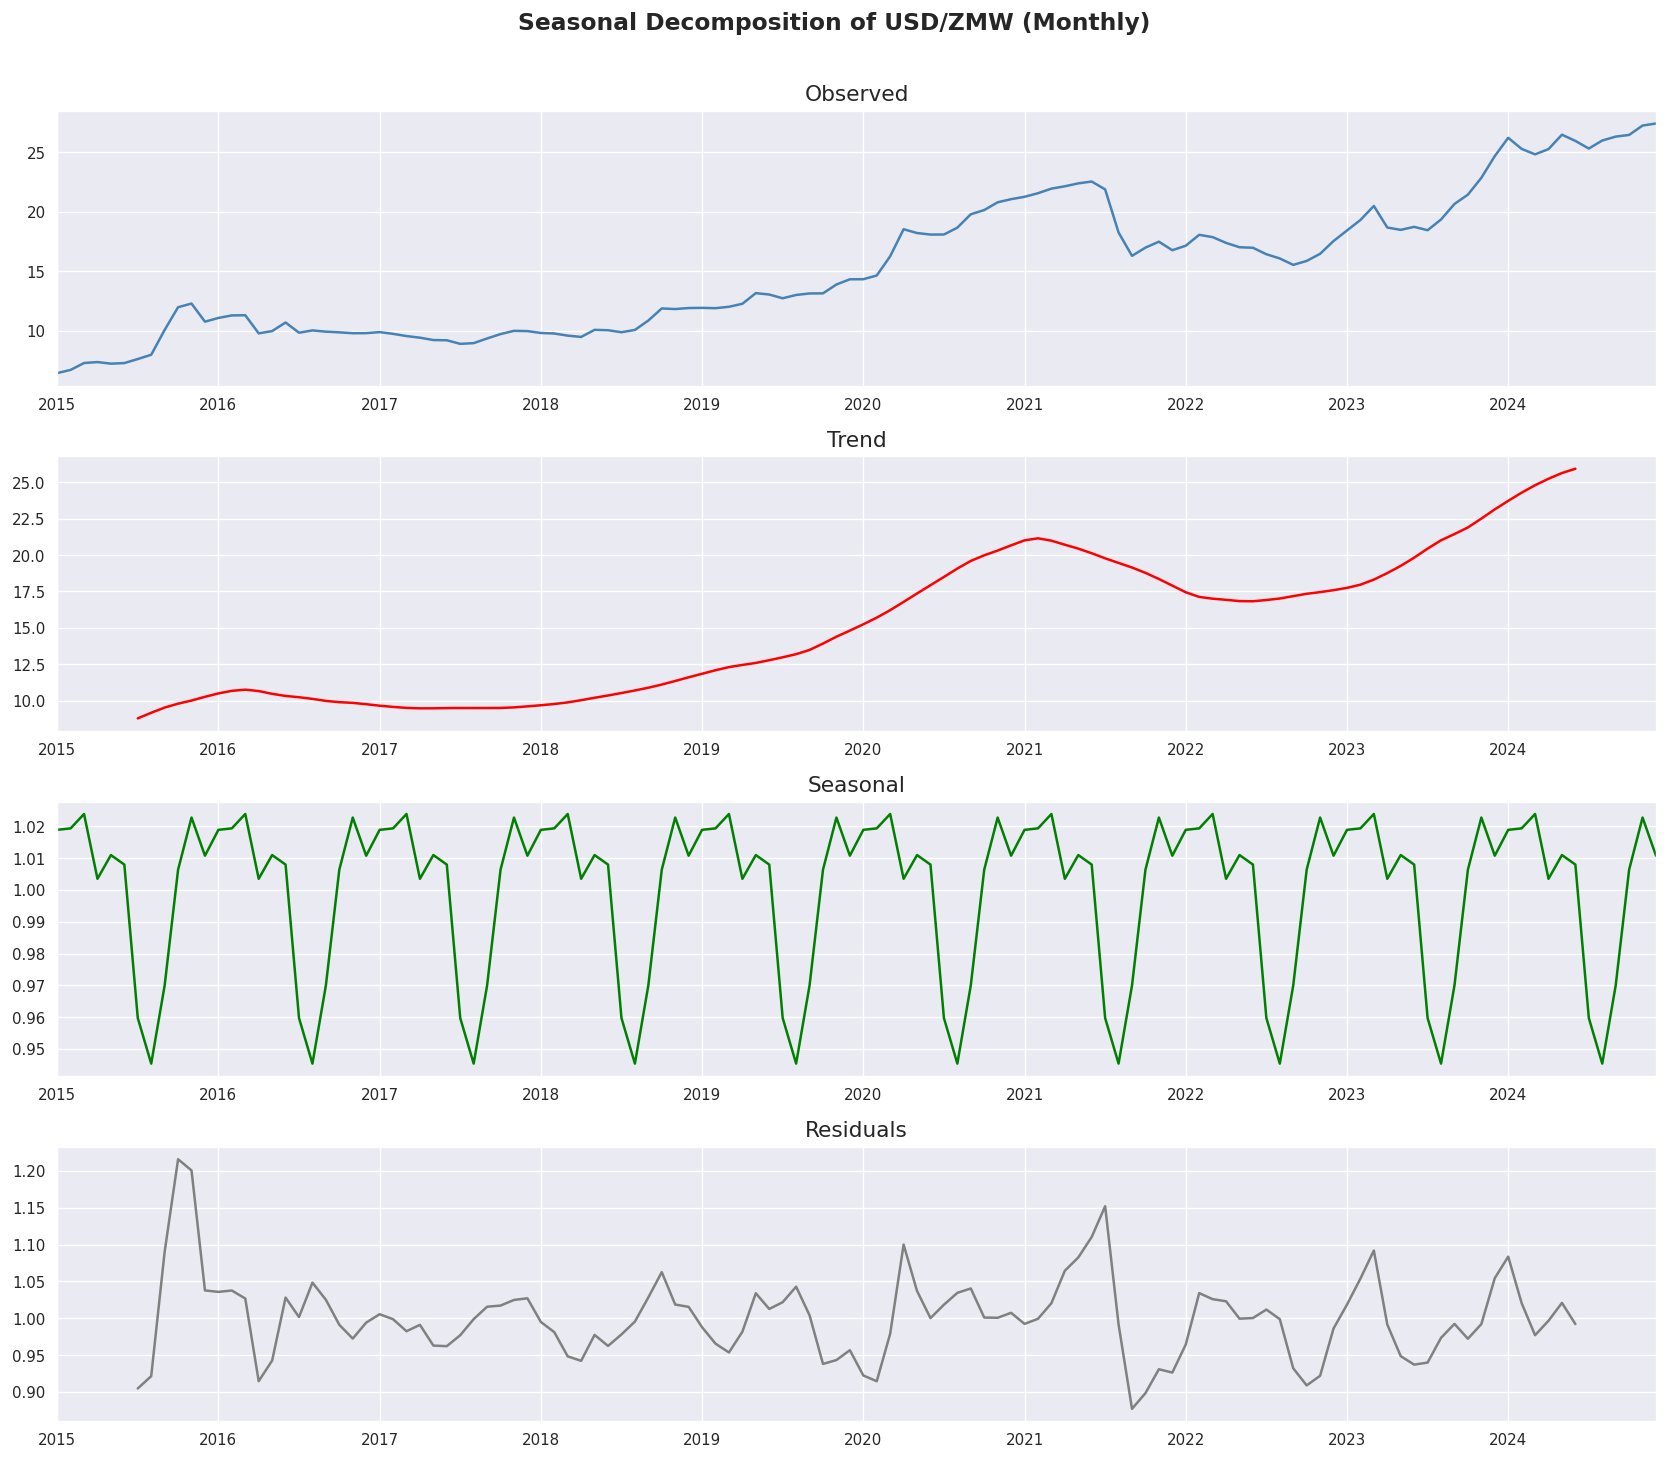

✅ Plot saved: outputs/03_decomposition.png


In [ ]:
# ============================================================
# CODE CELL 3.4 - Seasonal Decomposition
# ============================================================

from statsmodels.tsa.seasonal import seasonal_decompose

# Resample to monthly for cleaner decomposition
monthly = df['USDZMW'].resample('M').mean()

decomp = seasonal_decompose(monthly, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

decomp.observed.plot(ax=axes[0],  title='Observed',   color='steelblue')
decomp.trend.plot(ax=axes[1],     title='Trend',      color='red')
decomp.seasonal.plot(ax=axes[2],  title='Seasonal',   color='green')
decomp.resid.plot(ax=axes[3],     title='Residuals',  color='gray')

for ax in axes:
    ax.set_xlabel('')

fig.suptitle('Seasonal Decomposition of USD/ZMW (Monthly)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/03_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: outputs/03_decomposition.png")

In [ ]:
# ============================================================
# CODE CELL 3.5 - Augmented Dickey-Fuller (ADF) Stationarity Test
# ============================================================

def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n{'='*50}")
    print(f"  ADF Test: {name}")
    print(f"{'='*50}")
    print(f"  ADF Statistic  : {result[0]:.6f}")
    print(f"  p-value        : {result[1]:.6f}")
    print(f"  Lags Used      : {result[2]}")
    print(f"  Observations   : {result[3]}")
    print(f"  Critical Values:")
    for level, cval in result[4].items():
        flag = " <-- ADF stat is beyond this" if result[0] < cval else ""
        print(f"     {level} : {cval:.4f}{flag}")
    print()
    if result[1] <= 0.05:
        print(f"  VERDICT: STATIONARY (p <= 0.05) ✅")
    else:
        print(f"  VERDICT: NON-STATIONARY (p > 0.05) ❌ -- differencing required")

adf_test(df['USDZMW'],             "Original USD/ZMW Series")
adf_test(df['log_USDZMW'],         "Log-Transformed Series")
adf_test(df['log_USDZMW'].diff(),  "Log-Differenced Series (d=1)")


  ADF Test: Original USD/ZMW Series
  ADF Statistic  : -0.315936
  p-value        : 0.923217
  Lags Used      : 16
  Observations   : 2591
  Critical Values:
     1% : -3.4329
     5% : -2.8627
     10% : -2.5674

  VERDICT: NON-STATIONARY (p > 0.05) ❌ -- differencing required

  ADF Test: Log-Transformed Series
  ADF Statistic  : -1.307899
  p-value        : 0.625551
  Lags Used      : 12
  Observations   : 2595
  Critical Values:
     1% : -3.4329
     5% : -2.8627
     10% : -2.5674

  VERDICT: NON-STATIONARY (p > 0.05) ❌ -- differencing required

  ADF Test: Log-Differenced Series (d=1)
  ADF Statistic  : -14.301520
  p-value        : 0.000000
  Lags Used      : 11
  Observations   : 2595
  Critical Values:
     1% : -3.4329 <-- ADF stat is beyond this
     5% : -2.8627 <-- ADF stat is beyond this
     10% : -2.5674 <-- ADF stat is beyond this

  VERDICT: STATIONARY (p <= 0.05) ✅


  TRAIN / TEST SPLIT
  Total samples  : 2,608
  Training rows  : 2,086  (80.0%)
  Test rows      : 522   (20.0%)
  Train period   : 2015-01-01 to 2022-12-29
  Test period    : 2022-12-30 to 2024-12-30


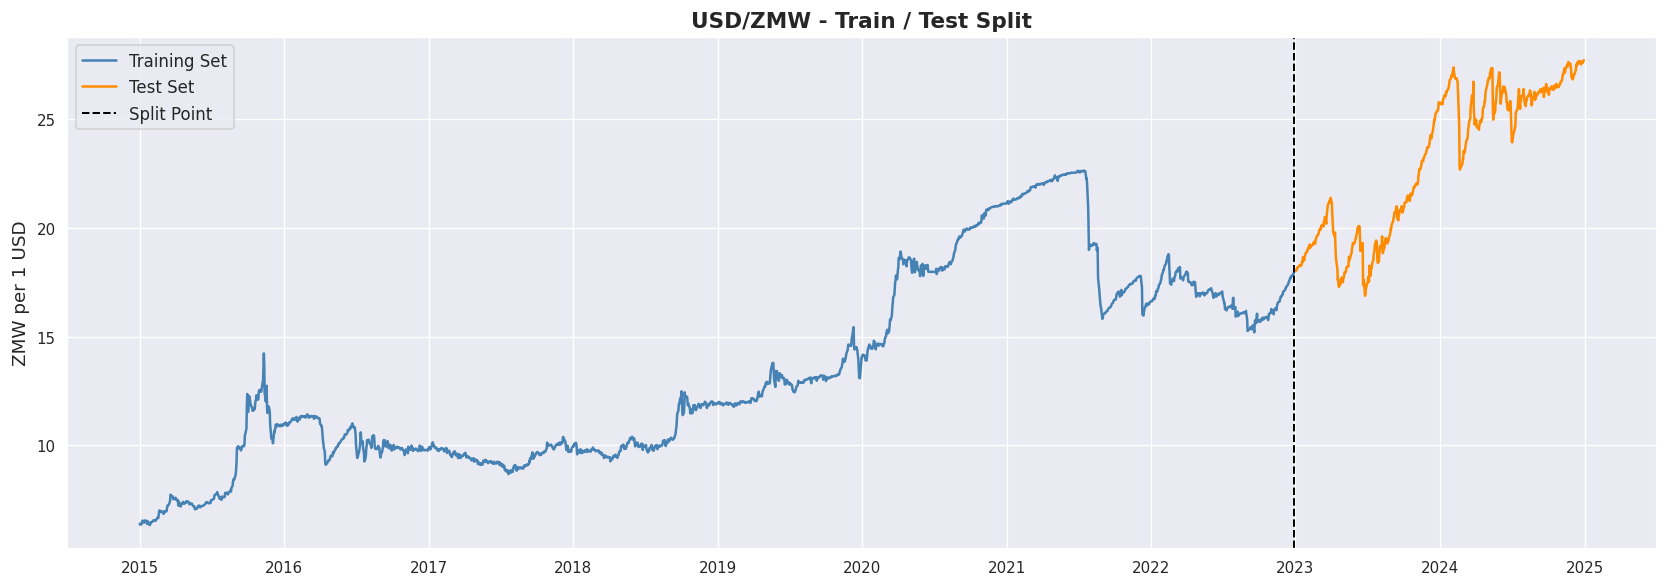

✅ Split plot saved: outputs/04_train_test_split.png


In [ ]:
# ============================================================
# CODE CELL 3.6 - Train / Test Split (80% / 20%)
# ============================================================

split_idx = int(len(df) * 0.80)

train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()

print("=" * 50)
print("  TRAIN / TEST SPLIT")
print("=" * 50)
print(f"  Total samples  : {len(df):,}")
print(f"  Training rows  : {len(train):,}  ({len(train)/len(df)*100:.1f}%)")
print(f"  Test rows      : {len(test):,}   ({len(test)/len(df)*100:.1f}%)")
print(f"  Train period   : {train.index.min().date()} to {train.index.max().date()}")
print(f"  Test period    : {test.index.min().date()} to {test.index.max().date()}")
print("=" * 50)

# Visualise the split
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train['USDZMW'], label='Training Set', color='steelblue')
ax.plot(test.index,  test['USDZMW'],  label='Test Set',     color='darkorange')
ax.axvline(train.index[-1], color='black', linestyle='--', linewidth=1.2, label='Split Point')
ax.set_title('USD/ZMW - Train / Test Split', fontweight='bold', fontsize=13)
ax.set_ylabel('ZMW per 1 USD')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/04_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Split plot saved: outputs/04_train_test_split.png")

---
<a name="stage4"></a>

## Stage 4 - ARIMA Modelling

The ADF test confirmed that the log-differenced series (d=1) is stationary.
We now build the ARIMA model using three steps:

1. ACF and PACF plots to visually identify candidate (p, q) values
2. auto_arima to automatically select the best (p, d, q) by AIC
3. Fit the final ARIMA model and generate test-set forecasts

**What is ARIMA?**
- p = AutoRegressive order (how many past values to use)
- d = degree of differencing (we confirmed d=1 from ADF test)
- q = Moving Average order (how many past errors to use)

---

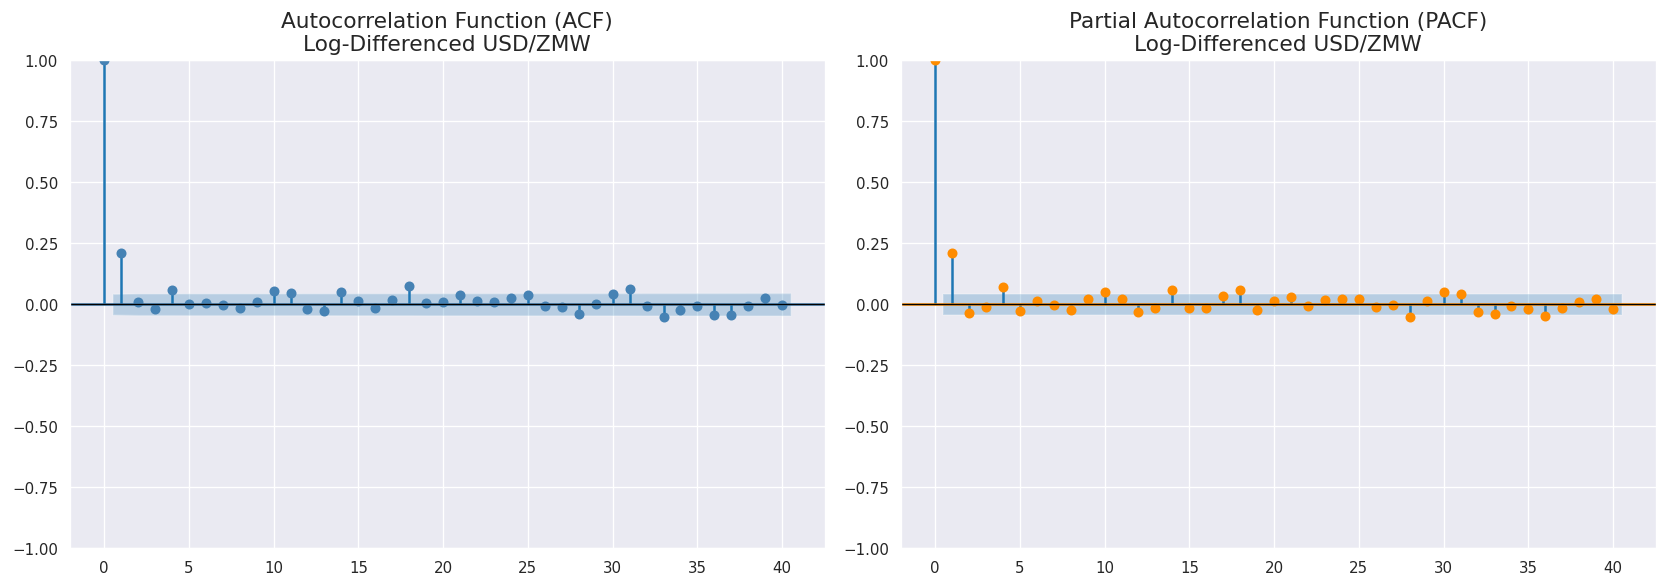

✅ ACF/PACF plot saved: outputs/05_acf_pacf.png

READING THE PLOTS:
  ACF  cuts off at lag k  -> MA order q = k
  PACF cuts off at lag k  -> AR order p = k
  auto_arima below will confirm the best order automatically.


In [ ]:
# ============================================================
# CODE CELL 4.1 - ACF and PACF Plots
# These help us visually identify p and q for ARIMA
# ============================================================

# Use the log-differenced series (stationary)
diff_series = train['log_USDZMW'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(diff_series,  lags=40, ax=axes[0],
         title='Autocorrelation Function (ACF)\nLog-Differenced USD/ZMW',
         color='steelblue')

plot_pacf(diff_series, lags=40, ax=axes[1],
          title='Partial Autocorrelation Function (PACF)\nLog-Differenced USD/ZMW',
          color='darkorange', method='ywm')

axes[0].axhline(y=0,    color='black', linewidth=0.8)
axes[1].axhline(y=0,    color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('outputs/05_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ACF/PACF plot saved: outputs/05_acf_pacf.png")
print()
print("READING THE PLOTS:")
print("  ACF  cuts off at lag k  -> MA order q = k")
print("  PACF cuts off at lag k  -> AR order p = k")
print("  auto_arima below will confirm the best order automatically.")

In [ ]:
# ============================================================
# CODE CELL 4.2 - Auto ARIMA: Automatic Order Selection
# Searches for best (p,d,q) using AIC criterion
# This may take 2-4 minutes - please wait
# ============================================================

print("Running auto_arima search...")
print("This searches all combinations of p=0..4, q=0..4 with d=1")
print("Selecting the model with the lowest AIC score...")
print()

arima_search = auto_arima(
    train['log_USDZMW'],
    start_p=0, max_p=4,
    start_q=0, max_q=4,
    d=1,
    seasonal=False,
    information_criterion='aic',
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

p, d, q = arima_search.order

print()
print("=" * 50)
print("  AUTO ARIMA RESULT")
print("=" * 50)
print(f"  Best order : ARIMA({p}, {d}, {q})")
print(f"  AIC score  : {arima_search.aic():.4f}")
print(f"  BIC score  : {arima_search.bic():.4f}")
print("=" * 50)

Running auto_arima search...
This searches all combinations of p=0..4, q=0..4 with d=1
Selecting the model with the lowest AIC score...

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-13021.725, Time=0.70 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-13111.971, Time=0.39 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-13113.293, Time=0.84 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-13019.173, Time=0.28 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-13112.148, Time=1.29 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-13112.557, Time=2.63 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-13114.355, Time=3.37 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-13117.931, Time=4.87 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-13109.986, Time=4.34 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-13118.318, Time=5.36 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-13109.714, Time=2.46 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=-13115.519, Time=1.97 sec
 ARI

In [ ]:
# ============================================================
# CODE CELL 4.3 - Fit the Final ARIMA Model
# ============================================================

print(f"Fitting ARIMA({p},{d},{q}) on training data...")

arima_model = ARIMA(train['log_USDZMW'], order=(p, d, q)).fit()

print(arima_model.summary())
print()
print("=" * 50)
print("  MODEL DIAGNOSTICS")
print("=" * 50)
print(f"  AIC  : {arima_model.aic:.4f}")
print(f"  BIC  : {arima_model.bic:.4f}")
print(f"  HQIC : {arima_model.hqic:.4f}")
print("=" * 50)
print("  Lower AIC/BIC = better model fit")

Fitting ARIMA(3,1,2) on training data...
                               SARIMAX Results                                
Dep. Variable:             log_USDZMW   No. Observations:                 2086
Model:                 ARIMA(3, 1, 2)   Log Likelihood                6562.137
Date:                Fri, 29 May 2026   AIC                         -13112.274
Time:                        07:12:28   BIC                         -13078.419
Sample:                    01-01-2015   HQIC                        -13099.869
                         - 12-29-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3465      0.249     -1.393      0.164      -0.834       0.141
ar.L2         -0.1302      0.188     -0.692      0.489      -0.499       0.239
ar.L3      

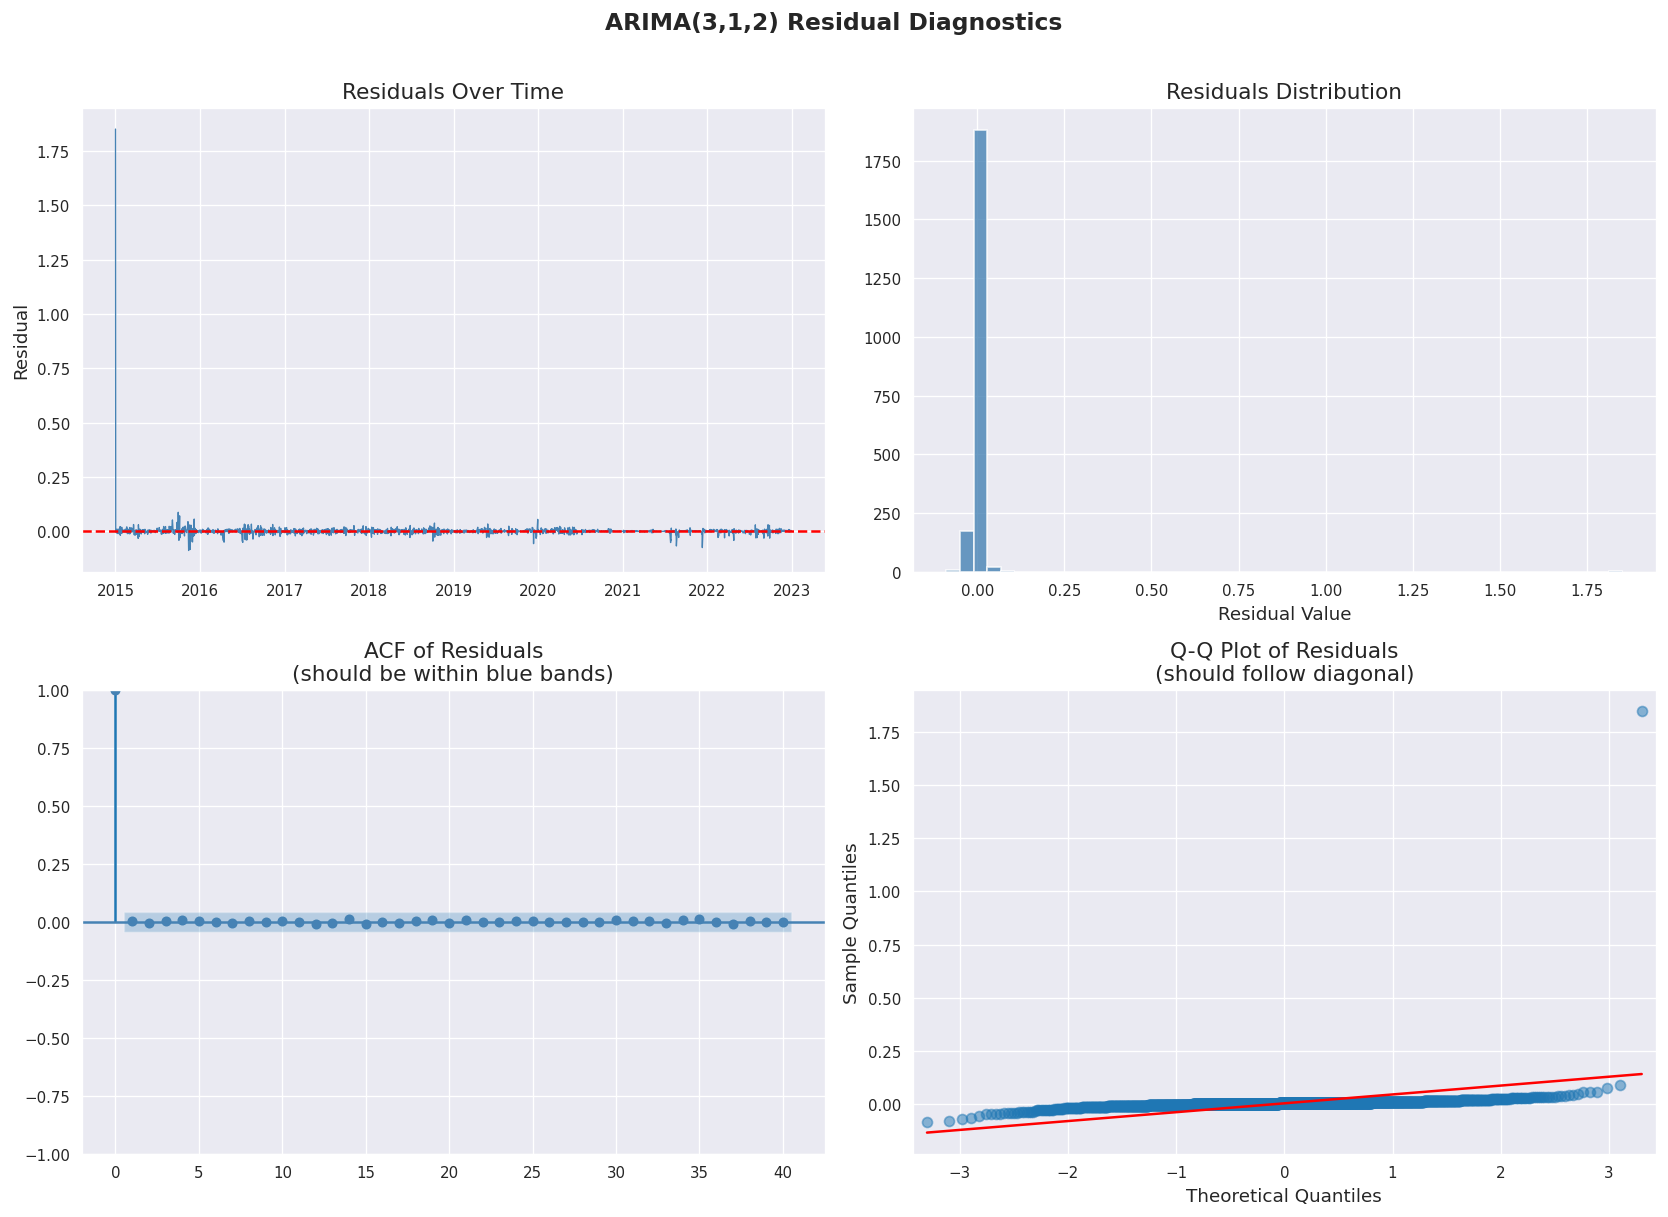

✅ Diagnostics saved: outputs/06_arima_diagnostics.png


In [ ]:
# ============================================================
# CODE CELL 4.4 - ARIMA Residual Diagnostics
# Good residuals should look like white noise (random)
# ============================================================

residuals = arima_model.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals over time
axes[0,0].plot(residuals, color='steelblue', linewidth=0.8)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title('Residuals Over Time')
axes[0,0].set_ylabel('Residual')

# 2. Residuals histogram
axes[0,1].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Residuals Distribution')
axes[0,1].set_xlabel('Residual Value')

# 3. ACF of residuals (should be near zero for all lags)
plot_acf(residuals, lags=40, ax=axes[1,0],
         title='ACF of Residuals\n(should be within blue bands)', color='steelblue')

# 4. Q-Q plot (should be close to diagonal line)
from statsmodels.graphics.gofplots import qqplot
qqplot(residuals, line='s', ax=axes[1,1], alpha=0.5)
axes[1,1].set_title('Q-Q Plot of Residuals\n(should follow diagonal)')

plt.suptitle(f'ARIMA({p},{d},{q}) Residual Diagnostics', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/06_arima_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Diagnostics saved: outputs/06_arima_diagnostics.png")

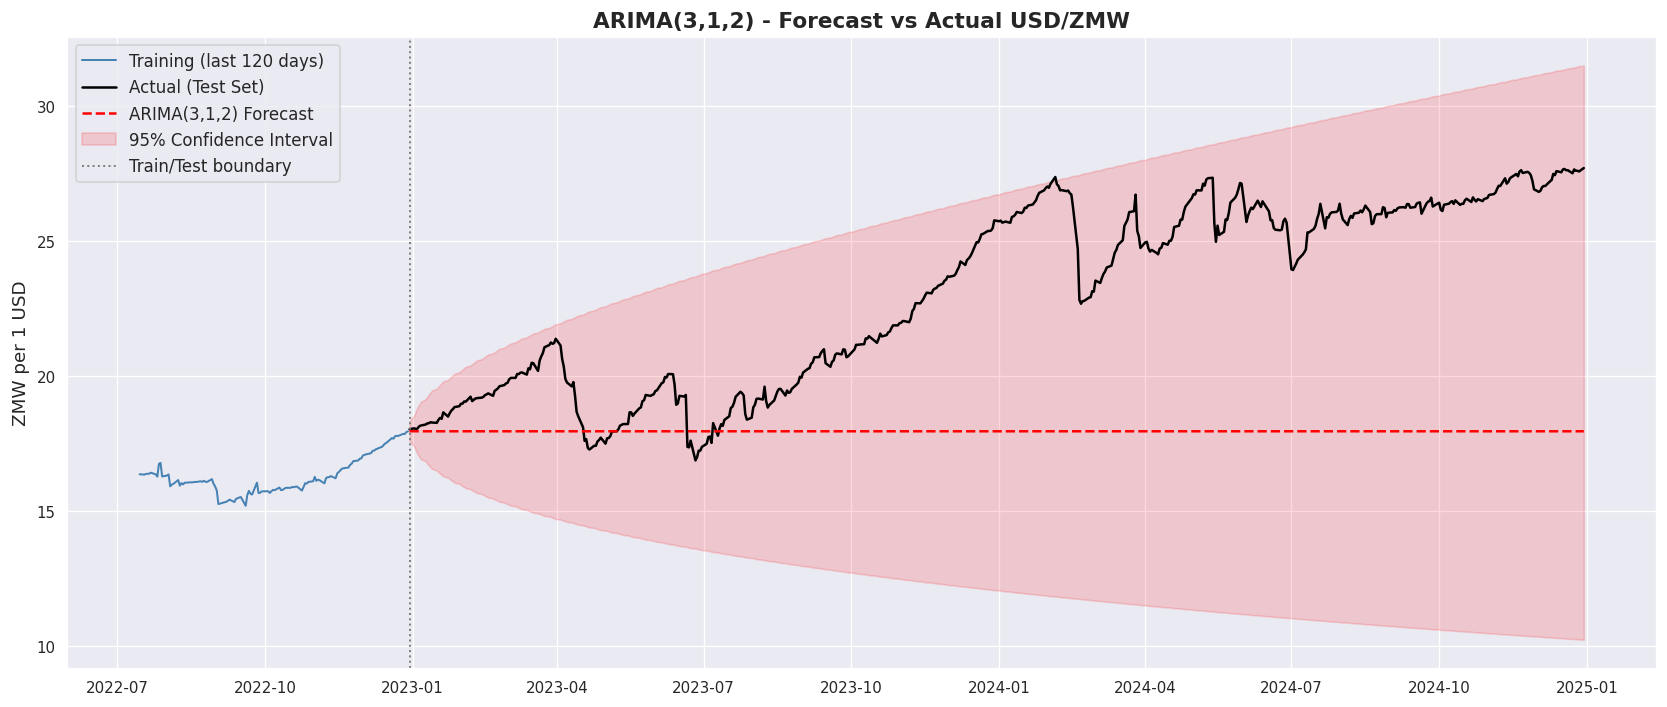

✅ ARIMA forecast plot saved: outputs/07_arima_forecast.png


In [ ]:
# ============================================================
# CODE CELL 4.5 - ARIMA Forecast on Test Set
# ============================================================

n_test = len(test)

# Get forecast + confidence intervals
forecast_obj      = arima_model.get_forecast(steps=n_test)
forecast_log      = forecast_obj.predicted_mean
forecast_ci_log   = forecast_obj.conf_int(alpha=0.05)

# Back-transform from log scale to original ZMW scale
arima_pred        = np.exp(forecast_log)
ci_lower          = np.exp(forecast_ci_log.iloc[:, 0])
ci_upper          = np.exp(forecast_ci_log.iloc[:, 1])

# Align index with test dates
arima_pred.index  = test.index
ci_lower.index    = test.index
ci_upper.index    = test.index

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train['USDZMW'].iloc[-120:], label='Training (last 120 days)',
        color='steelblue', linewidth=1.2)
ax.plot(test['USDZMW'],              label='Actual (Test Set)',
        color='black', linewidth=1.5)
ax.plot(test.index, arima_pred,      label=f'ARIMA({p},{d},{q}) Forecast',
        color='red', linewidth=1.5, linestyle='--')
ax.fill_between(test.index, ci_lower, ci_upper,
                alpha=0.15, color='red', label='95% Confidence Interval')

ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1.2, label='Train/Test boundary')
ax.set_title(f'ARIMA({p},{d},{q}) - Forecast vs Actual USD/ZMW', fontweight='bold', fontsize=13)
ax.set_ylabel('ZMW per 1 USD')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('outputs/07_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ARIMA forecast plot saved: outputs/07_arima_forecast.png")

In [ ]:
# ============================================================
# CODE CELL 4.6 - ARIMA Forecast Evaluation Metrics
# ============================================================

actual_test  = test['USDZMW'].values
arima_values = arima_pred.values

arima_rmse = np.sqrt(mean_squared_error(actual_test, arima_values))
arima_mae  = mean_absolute_error(actual_test, arima_values)
arima_mape = np.mean(np.abs((actual_test - arima_values) / actual_test)) * 100

print("=" * 50)
print(f"  ARIMA({p},{d},{q}) - TEST SET PERFORMANCE")
print("=" * 50)
print(f"  RMSE  : {arima_rmse:.4f} ZMW")
print(f"  MAE   : {arima_mae:.4f}  ZMW")
print(f"  MAPE  : {arima_mape:.2f}%")
print("=" * 50)
print()
print("  RMSE = Root Mean Squared Error (penalises large errors)")
print("  MAE  = Mean Absolute Error (average error in ZMW)")
print("  MAPE = Mean Absolute Percentage Error (% accuracy)")

# Save for comparison in Stage 6
arima_results = {
    'Model': f'ARIMA({p},{d},{q})',
    'RMSE' : round(arima_rmse, 4),
    'MAE'  : round(arima_mae,  4),
    'MAPE' : round(arima_mape, 2)
}
print()
print("✅ ARIMA metrics saved for final comparison in Stage 6.")

  ARIMA(3,1,2) - TEST SET PERFORMANCE
  RMSE  : 6.1406 ZMW
  MAE   : 5.1744  ZMW
  MAPE  : 20.70%

  RMSE = Root Mean Squared Error (penalises large errors)
  MAE  = Mean Absolute Error (average error in ZMW)
  MAPE = Mean Absolute Percentage Error (% accuracy)

✅ ARIMA metrics saved for final comparison in Stage 6.


---
<a name="stage5"></a>

## Stage 5 - LSTM (Long Short-Term Memory) Model

LSTM is a deep learning model designed for sequential time series data.
Unlike ARIMA, it requires no stationarity assumptions and can learn
complex non-linear patterns.

Our approach:
1. Scale data to [0,1] range using MinMaxScaler
2. Create sliding window sequences (lookback = 60 days)
3. Build a 2-layer LSTM network with Dropout regularisation
4. Train with Early Stopping to prevent overfitting
5. Generate predictions on the test set and inverse-transform back to ZMW

Key design choices:
- Lookback window : 60 business days (~3 months of context)
- LSTM units      : 64 (layer 1) and 32 (layer 2)
- Dropout rate    : 0.2 (prevents overfitting)
- Optimizer       : Adam
- Loss function   : Mean Squared Error (MSE)

---

In [ ]:
# ============================================================
# CODE CELL 5.1 - Scale Data with MinMaxScaler
# IMPORTANT: Fit scaler on TRAIN only, then transform both
# Fitting on full data would cause data leakage
# ============================================================

scaler = MinMaxScaler(feature_range=(0, 1))

# Fit ONLY on training data
train_scaled = scaler.fit_transform(train[['USDZMW']])

# Transform test data using the same scaler (no re-fitting)
test_scaled  = scaler.transform(test[['USDZMW']])

print("=" * 50)
print("  DATA SCALING REPORT")
print("=" * 50)
print(f"  Scaler           : MinMaxScaler [0, 1]")
print(f"  Train min (orig) : {scaler.data_min_[0]:.4f} ZMW")
print(f"  Train max (orig) : {scaler.data_max_[0]:.4f} ZMW")
print(f"  Train scaled min : {train_scaled.min():.4f}")
print(f"  Train scaled max : {train_scaled.max():.4f}")
print(f"  Test  scaled min : {test_scaled.min():.4f}")
print(f"  Test  scaled max : {test_scaled.max():.4f}")
print("=" * 50)
print()
print("NOTE: Test max may exceed 1.0 — this is normal.")
print("      It means the test period had higher rates than training.")
print("✅ Scaling complete.")

  DATA SCALING REPORT
  Scaler           : MinMaxScaler [0, 1]
  Train min (orig) : 6.3243 ZMW
  Train max (orig) : 22.6371 ZMW
  Train scaled min : 0.0000
  Train scaled max : 1.0000
  Test  scaled min : 0.6467
  Test  scaled max : 1.3110

NOTE: Test max may exceed 1.0 — this is normal.
      It means the test period had higher rates than training.
✅ Scaling complete.


In [ ]:
# ============================================================
# CODE CELL 5.2 - Create Sliding Window Sequences
# Each sample: X = past 60 days, y = next day price
# ============================================================

LOOKBACK = 60   # Number of past days the model looks back

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])   # past 60 values
        y.append(data[i, 0])                  # value to predict
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, LOOKBACK)

# For test: we prepend the last LOOKBACK rows of train
# so the first test prediction has full context
combined         = np.concatenate([train_scaled[-LOOKBACK:], test_scaled])
X_test,  y_test  = create_sequences(combined, LOOKBACK)

# Reshape to [samples, timesteps, features] — required by Keras LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape ((X_test.shape[0],  X_test.shape[1],  1))

print("=" * 50)
print("  SEQUENCE CREATION REPORT")
print("=" * 50)
print(f"  Lookback window  : {LOOKBACK} days")
print(f"  X_train shape    : {X_train.shape}  [samples, timesteps, features]")
print(f"  y_train shape    : {y_train.shape}")
print(f"  X_test  shape    : {X_test.shape}")
print(f"  y_test  shape    : {y_test.shape}")
print("=" * 50)
print("✅ Sequences ready for LSTM input.")

  SEQUENCE CREATION REPORT
  Lookback window  : 60 days
  X_train shape    : (2026, 60, 1)  [samples, timesteps, features]
  y_train shape    : (2026,)
  X_test  shape    : (522, 60, 1)
  y_test  shape    : (522,)
✅ Sequences ready for LSTM input.


In [ ]:
# ============================================================
# CODE CELL 5.3 - Build the LSTM Neural Network
# Architecture: LSTM(64) -> Dropout -> LSTM(32) -> Dropout
#               -> Dense(16) -> Dense(1)
# ============================================================

tf.random.set_seed(SEED)

model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(LOOKBACK, 1),
         name='lstm_layer_1'),
    Dropout(0.2, name='dropout_1'),

    LSTM(32, return_sequences=False,
         name='lstm_layer_2'),
    Dropout(0.2, name='dropout_2'),

    Dense(16, activation='relu', name='dense_hidden'),
    Dense(1,  activation='linear', name='output')
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

print("=" * 50)
print("  LSTM MODEL ARCHITECTURE")
print("=" * 50)
model.summary()
print()
print(f"  Total parameters : {model.count_params():,}")
print("✅ Model built successfully.")

  LSTM MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer_1 (LSTM)             │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_2 (LSTM)             │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


  Total parameters : 29,857
✅ Model built successfully.


In [ ]:
# ============================================================
# CODE CELL 5.4 - Train the LSTM Model
# Uses Early Stopping to stop when validation loss stops improving
# Also reduces learning rate when progress stalls
# Expected training time: 3-8 minutes on Colab CPU
# ============================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

print("Starting LSTM training...")
print(f"Max epochs : 150  |  Batch size : 32  |  Validation : 10%")
print()

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

best_epoch = np.argmin(history.history['val_loss']) + 1
print()
print("=" * 50)
print("  TRAINING COMPLETE")
print("=" * 50)
print(f"  Best epoch       : {best_epoch}")
print(f"  Final train loss : {history.history['loss'][-1]:.6f}")
print(f"  Final val loss   : {history.history['val_loss'][-1]:.6f}")
print("=" * 50)

Starting LSTM training...
Max epochs : 150  |  Batch size : 32  |  Validation : 10%

Epoch 1/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - loss: 0.0323 - mae: 0.1132 - val_loss: 6.6148e-04 - val_mae: 0.0209 - learning_rate: 0.0010
Epoch 2/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0043 - mae: 0.0453 - val_loss: 3.7106e-04 - val_mae: 0.0159 - learning_rate: 0.0010
Epoch 3/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0042 - mae: 0.0437 - val_loss: 5.0640e-04 - val_mae: 0.0181 - learning_rate: 0.0010
Epoch 4/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0029 - mae: 0.0371 - val_loss: 4.2595e-04 - val_mae: 0.0171 - learning_rate: 0.0010
Epoch 5/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0033 - mae: 0.0389 - val_loss: 0.0013 - val_mae: 0.0316 - learning_rate: 0.0010
Epoch 6/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0030 - mae: 0.0369 - val_loss: 0.0011 - val_mae: 0.0298 - learning_rate: 0.0010
Epoch 7/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms

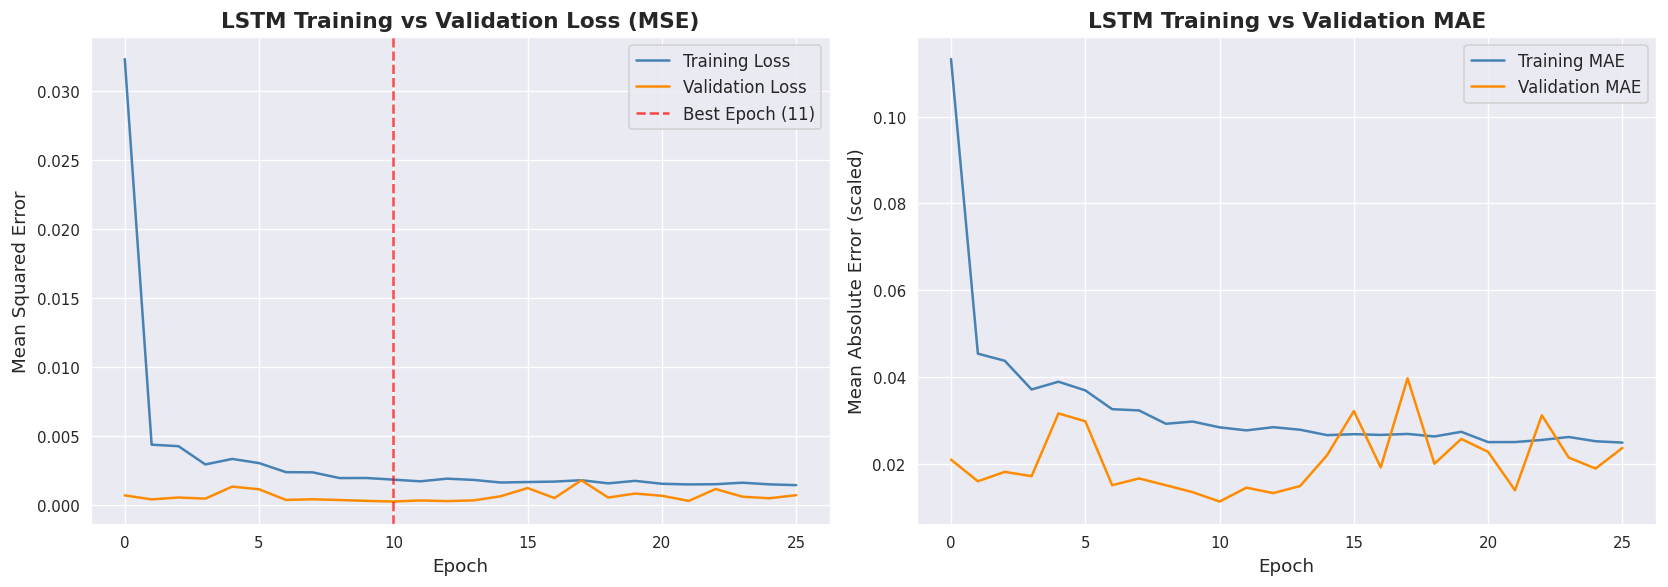

✅ Training loss plot saved: outputs/08_lstm_training_loss.png


In [ ]:
# ============================================================
# CODE CELL 5.5 - Plot Training and Validation Loss
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history.history['loss'],     label='Training Loss',   color='steelblue',  linewidth=1.5)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=1.5)
axes[0].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.7,
                label=f'Best Epoch ({best_epoch})')
axes[0].set_title('LSTM Training vs Validation Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Mean Squared Error')
axes[0].legend()

# MAE curves
axes[1].plot(history.history['mae'],     label='Training MAE',   color='steelblue',  linewidth=1.5)
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='darkorange', linewidth=1.5)
axes[1].set_title('LSTM Training vs Validation MAE', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Absolute Error (scaled)')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/08_lstm_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training loss plot saved: outputs/08_lstm_training_loss.png")

In [ ]:
# ============================================================
# CODE CELL 5.6 - Generate LSTM Predictions on Test Set
# ============================================================

# Predict (outputs are in scaled [0,1] range)
lstm_pred_scaled = model.predict(X_test, verbose=0)

# Inverse transform back to original ZMW scale
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)

# Also inverse transform actual test values for clean comparison
actual_test_vals = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"Predictions generated: {len(lstm_pred)} values")
print(f"Test set length      : {len(test)} values")
print()
print("Sample predictions vs actual (first 5):")
print(f"{'Date':<15} {'Actual':>10} {'Predicted':>12} {'Error':>10}")
print("-" * 50)
for i in range(5):
    date   = test.index[i].strftime('%Y-%m-%d')
    actual = actual_test_vals[i, 0]
    pred   = lstm_pred[i, 0]
    error  = actual - pred
    print(f"{date:<15} {actual:>10.4f} {pred:>12.4f} {error:>10.4f}")

print()
print("✅ LSTM predictions complete.")

Predictions generated: 522 values
Test set length      : 522 values

Sample predictions vs actual (first 5):
Date                Actual    Predicted      Error
--------------------------------------------------
2022-12-30         18.0322      17.7810     0.2512
2023-01-02         18.0643      17.8232     0.2412
2023-01-03         18.0300      17.8649     0.1651
2023-01-04         18.0622      17.9027     0.1595
2023-01-05         18.1380      17.9375     0.2005

✅ LSTM predictions complete.


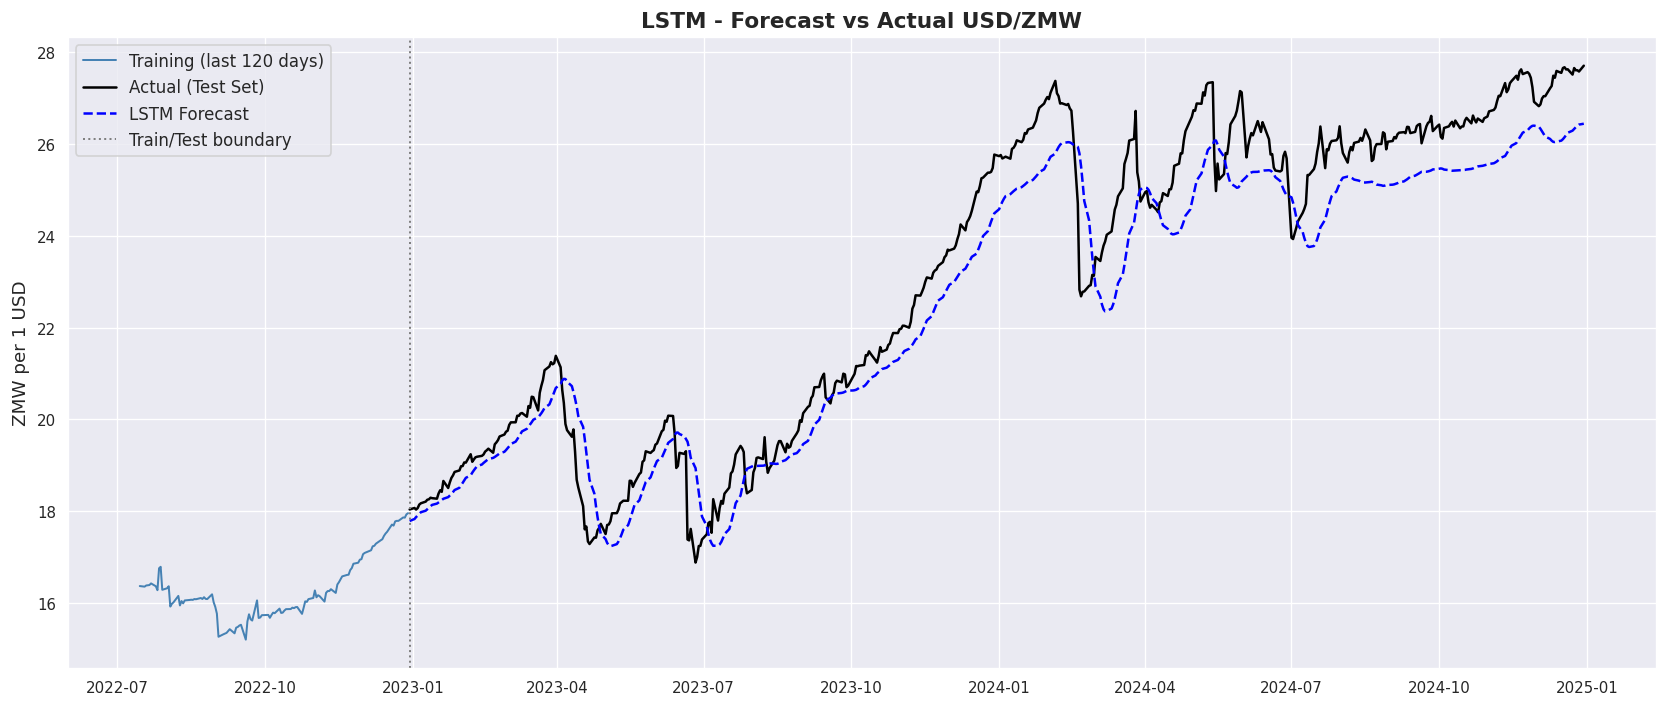

✅ LSTM forecast plot saved: outputs/09_lstm_forecast.png


In [ ]:
# ============================================================
# CODE CELL 5.7 - Plot LSTM Forecast vs Actual
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train['USDZMW'].iloc[-120:],
        label='Training (last 120 days)', color='steelblue', linewidth=1.2)
ax.plot(test.index, actual_test_vals,
        label='Actual (Test Set)', color='black', linewidth=1.5)
ax.plot(test.index, lstm_pred,
        label='LSTM Forecast', color='blue', linewidth=1.5, linestyle='--')

ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1.2,
           label='Train/Test boundary')
ax.set_title('LSTM - Forecast vs Actual USD/ZMW', fontweight='bold', fontsize=13)
ax.set_ylabel('ZMW per 1 USD')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('outputs/09_lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ LSTM forecast plot saved: outputs/09_lstm_forecast.png")

In [ ]:
# ============================================================
# CODE CELL 5.8 - LSTM Evaluation Metrics
# ============================================================

lstm_rmse = np.sqrt(mean_squared_error(actual_test_vals, lstm_pred))
lstm_mae  = mean_absolute_error(actual_test_vals, lstm_pred)
lstm_mape = np.mean(np.abs((actual_test_vals - lstm_pred) / actual_test_vals)) * 100

print("=" * 50)
print("  LSTM - TEST SET PERFORMANCE")
print("=" * 50)
print(f"  RMSE  : {lstm_rmse:.4f} ZMW")
print(f"  MAE   : {lstm_mae:.4f}  ZMW")
print(f"  MAPE  : {lstm_mape:.2f}%")
print("=" * 50)

# Save for comparison in Stage 6
lstm_results = {
    'Model': 'LSTM',
    'RMSE' : round(lstm_rmse, 4),
    'MAE'  : round(lstm_mae,  4),
    'MAPE' : round(lstm_mape, 2)
}

print()
print("  FOR REFERENCE - ARIMA(3,1,2) RESULTS:")
print(f"  RMSE  : {arima_results['RMSE']} ZMW")
print(f"  MAE   : {arima_results['MAE']}  ZMW")
print(f"  MAPE  : {arima_results['MAPE']}%")
print()
print("✅ LSTM metrics saved for final comparison in Stage 6.")

  LSTM - TEST SET PERFORMANCE
  RMSE  : 0.9868 ZMW
  MAE   : 0.8437  ZMW
  MAPE  : 3.57%

  FOR REFERENCE - ARIMA(3,1,2) RESULTS:
  RMSE  : 6.1406 ZMW
  MAE   : 5.1744  ZMW
  MAPE  : 20.7%

✅ LSTM metrics saved for final comparison in Stage 6.


---
<a name="stage6"></a>

## Stage 6 - Model Evaluation and Comparison

We now formally compare ARIMA(3,1,2) and LSTM side by side using:
- A metrics summary table (RMSE, MAE, MAPE)
- A side-by-side forecast overlay plot
- A bar chart comparing all three metrics visually

---

In [ ]:
# ============================================================
# CODE CELL 6.1 - Formal Metrics Comparison Table
# ============================================================

comparison_df = pd.DataFrame([arima_results, lstm_results])
comparison_df = comparison_df.set_index('Model')

print("=" * 55)
print("  FINAL MODEL COMPARISON — USD/ZMW FORECASTING")
print("=" * 55)
print(comparison_df.to_string())
print("=" * 55)

# Identify winner per metric
for metric in ['RMSE', 'MAE', 'MAPE']:
    winner = comparison_df[metric].idxmin()
    margin = comparison_df[metric].max() - comparison_df[metric].min()
    pct    = (margin / comparison_df[metric].max()) * 100
    print(f"  Best {metric:<5}: {winner}  (by {margin:.4f}, {pct:.1f}% improvement)")

print("=" * 55)

# Save to CSV
os.makedirs('outputs', exist_ok=True)
comparison_df.to_csv('outputs/model_comparison.csv')
print("\n✅ Comparison table saved: outputs/model_comparison.csv")

  FINAL MODEL COMPARISON — USD/ZMW FORECASTING
                RMSE     MAE   MAPE
Model                              
ARIMA(3,1,2)  6.1406  5.1744  20.70
LSTM          0.9868  0.8437   3.57
  Best RMSE : LSTM  (by 5.1538, 83.9% improvement)
  Best MAE  : LSTM  (by 4.3307, 83.7% improvement)
  Best MAPE : LSTM  (by 17.1300, 82.8% improvement)

✅ Comparison table saved: outputs/model_comparison.csv


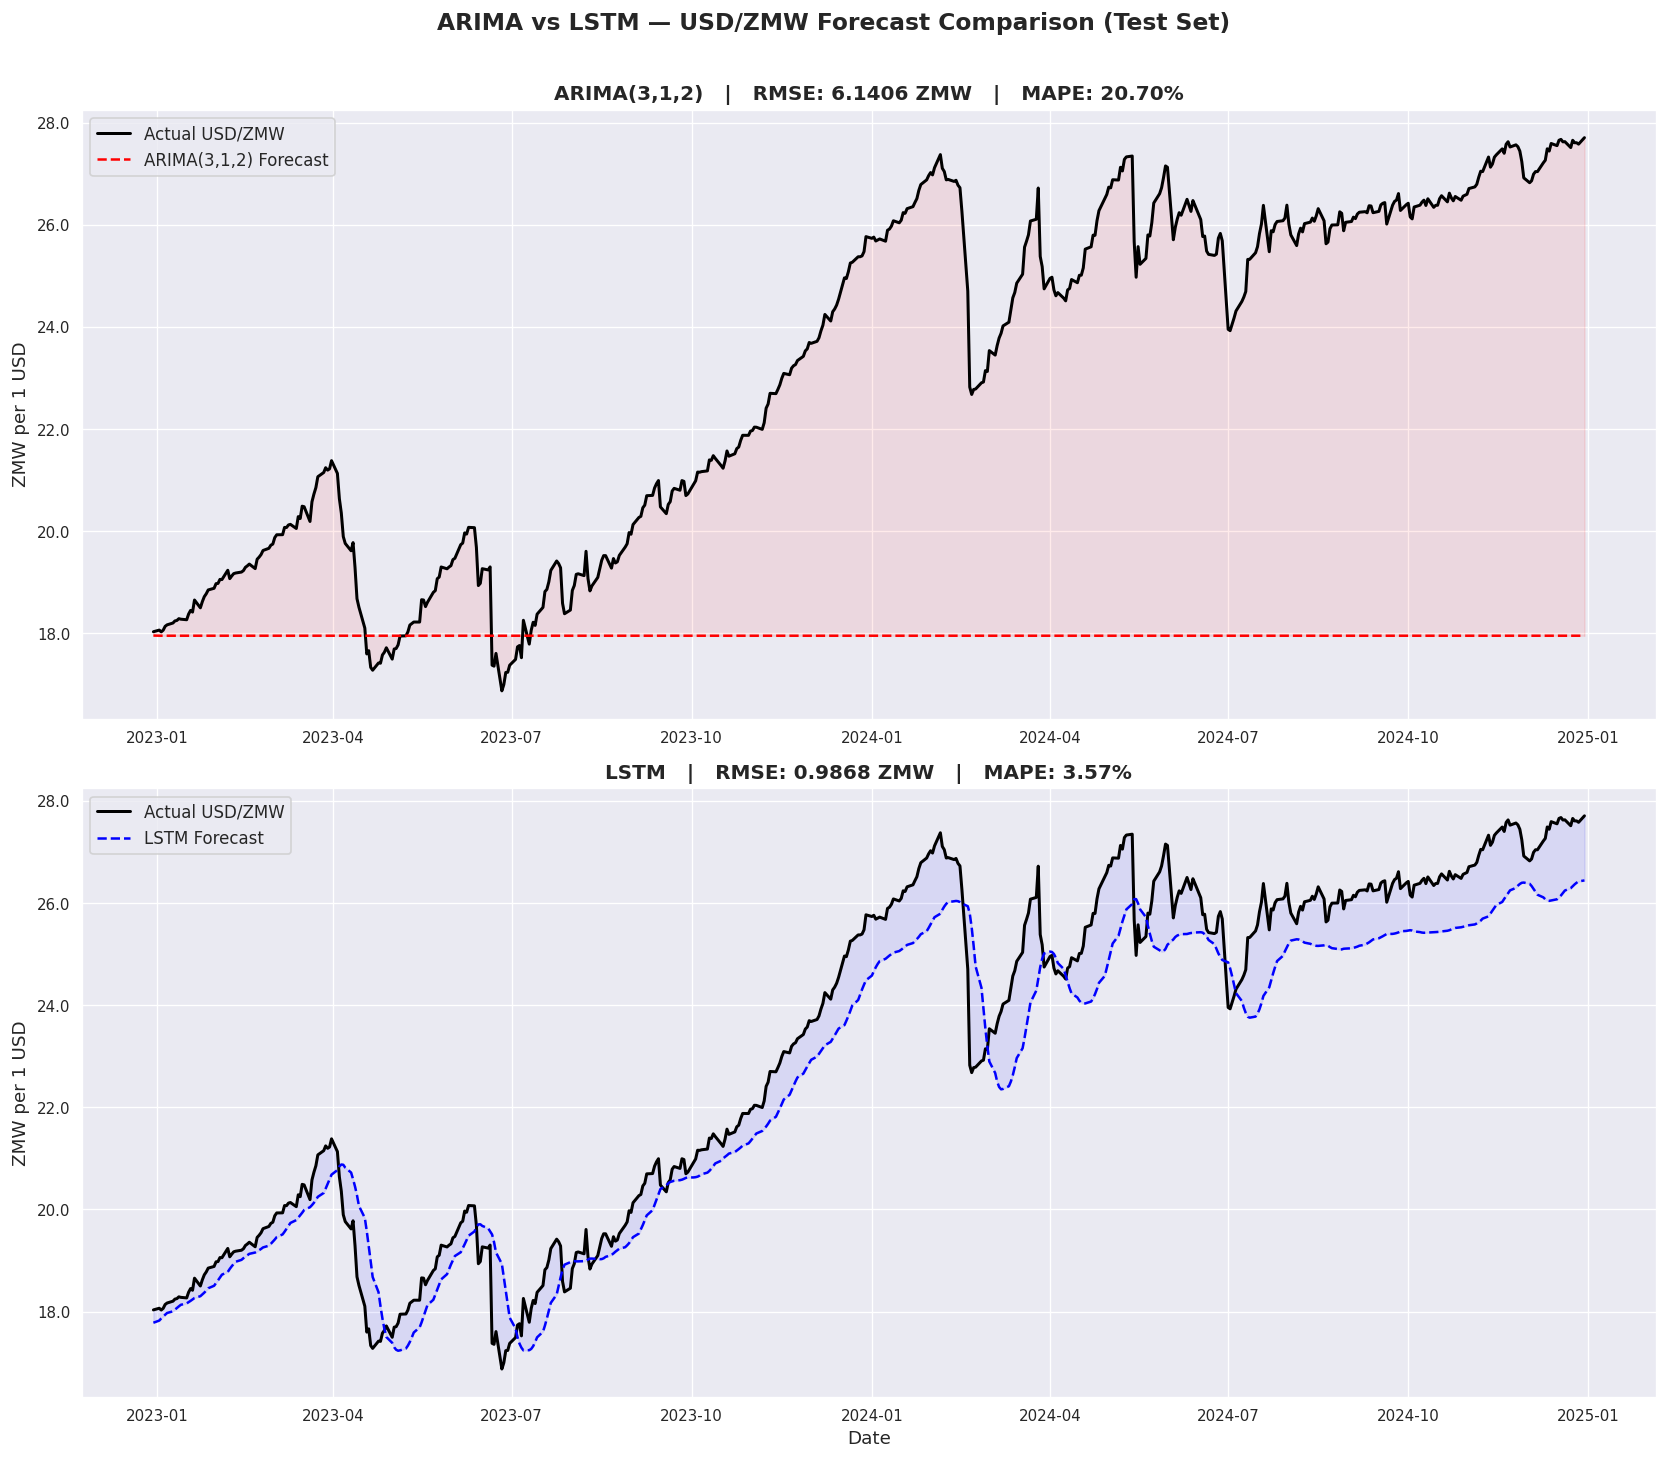

✅ Comparison plot saved: outputs/10_model_comparison.png


In [ ]:
# ============================================================
# CODE CELL 6.2 - Side-by-Side Forecast Comparison Plot
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

for ax, (pred, name, color, rmse, mape) in zip(axes, [
    (arima_pred.values,    f'ARIMA(3,1,2)', 'red',  arima_rmse, arima_mape),
    (lstm_pred.flatten(),  'LSTM',          'blue', lstm_rmse,  lstm_mape)
]):
    ax.plot(test.index, actual_test_vals,
            label='Actual USD/ZMW', color='black', linewidth=1.8)
    ax.plot(test.index, pred,
            label=f'{name} Forecast', color=color,
            linewidth=1.5, linestyle='--')
    ax.fill_between(test.index,
                    actual_test_vals.flatten(),
                    pred,
                    alpha=0.08, color=color)
    ax.set_title(f'{name}   |   RMSE: {rmse:.4f} ZMW   |   MAPE: {mape:.2f}%',
                 fontweight='bold', fontsize=12)
    ax.set_ylabel('ZMW per 1 USD')
    ax.legend(loc='upper left')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.1f}'))

axes[1].set_xlabel('Date')
fig.suptitle('ARIMA vs LSTM — USD/ZMW Forecast Comparison (Test Set)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/10_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison plot saved: outputs/10_model_comparison.png")

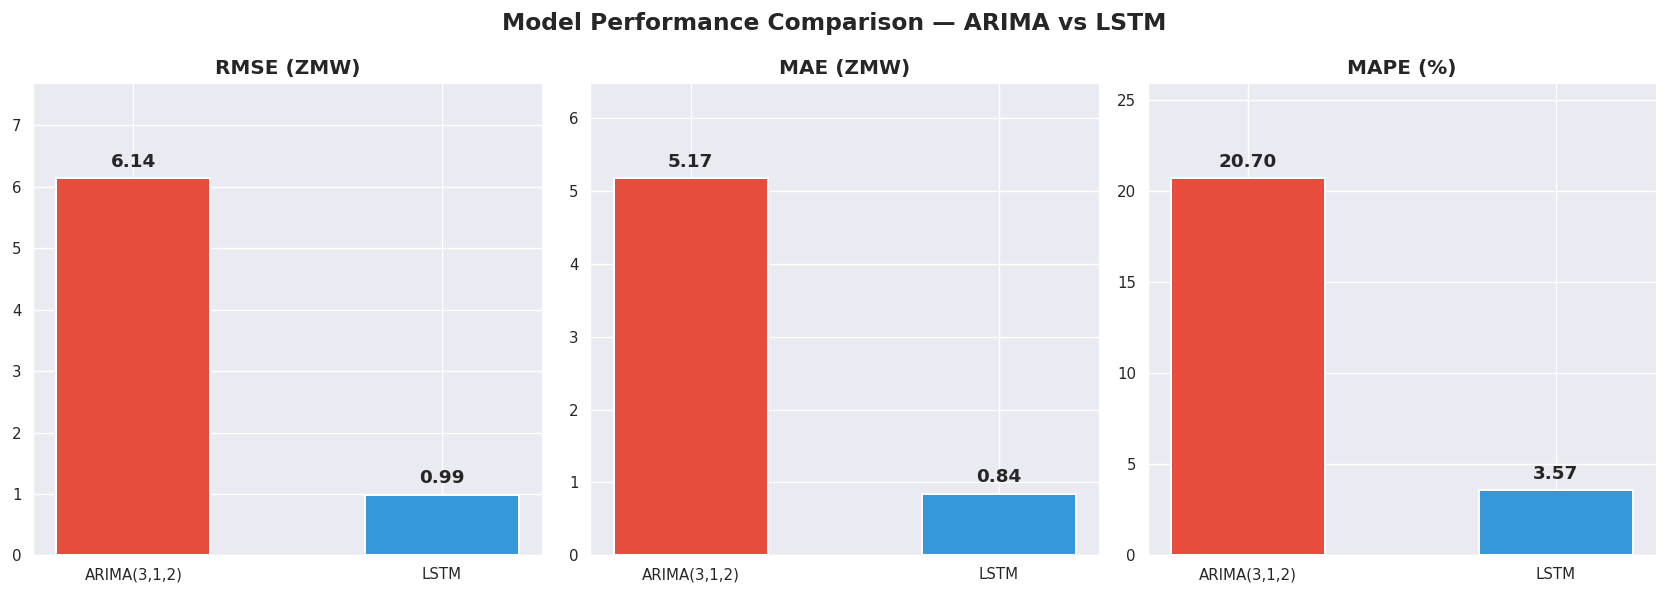

✅ Bar chart saved: outputs/11_metrics_barchart.png


In [ ]:
# ============================================================
# CODE CELL 6.3 - Metrics Bar Chart
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics  = ['RMSE', 'MAE', 'MAPE']
labels   = ['RMSE (ZMW)', 'MAE (ZMW)', 'MAPE (%)']
colors   = [['#e74c3c', '#3498db'],
            ['#e74c3c', '#3498db'],
            ['#e74c3c', '#3498db']]

for ax, metric, label, col in zip(axes, metrics, labels, colors):
    values = [arima_results[metric], lstm_results[metric]]
    models = ['ARIMA(3,1,2)', 'LSTM']
    bars   = ax.bar(models, values, color=col, edgecolor='white',
                    linewidth=1.2, width=0.5)

    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.02,
                f'{val:.2f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_ylim(0, max(values) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Model Performance Comparison — ARIMA vs LSTM',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/11_metrics_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Bar chart saved: outputs/11_metrics_barchart.png")

---
<a name="stage7"></a>

## Stage 7 - 30-Day Ahead Forecast

Using both models re-fitted on the FULL dataset (2015-2024),
we generate a 30-business-day forecast beyond December 2024.

- ARIMA: one-shot forecast with 95% confidence intervals
- LSTM : rolling one-step-ahead forecast (each prediction
         feeds back as input for the next step)

---

Re-fitting ARIMA(3,1,2) on full dataset (2015-2024)...
Done.


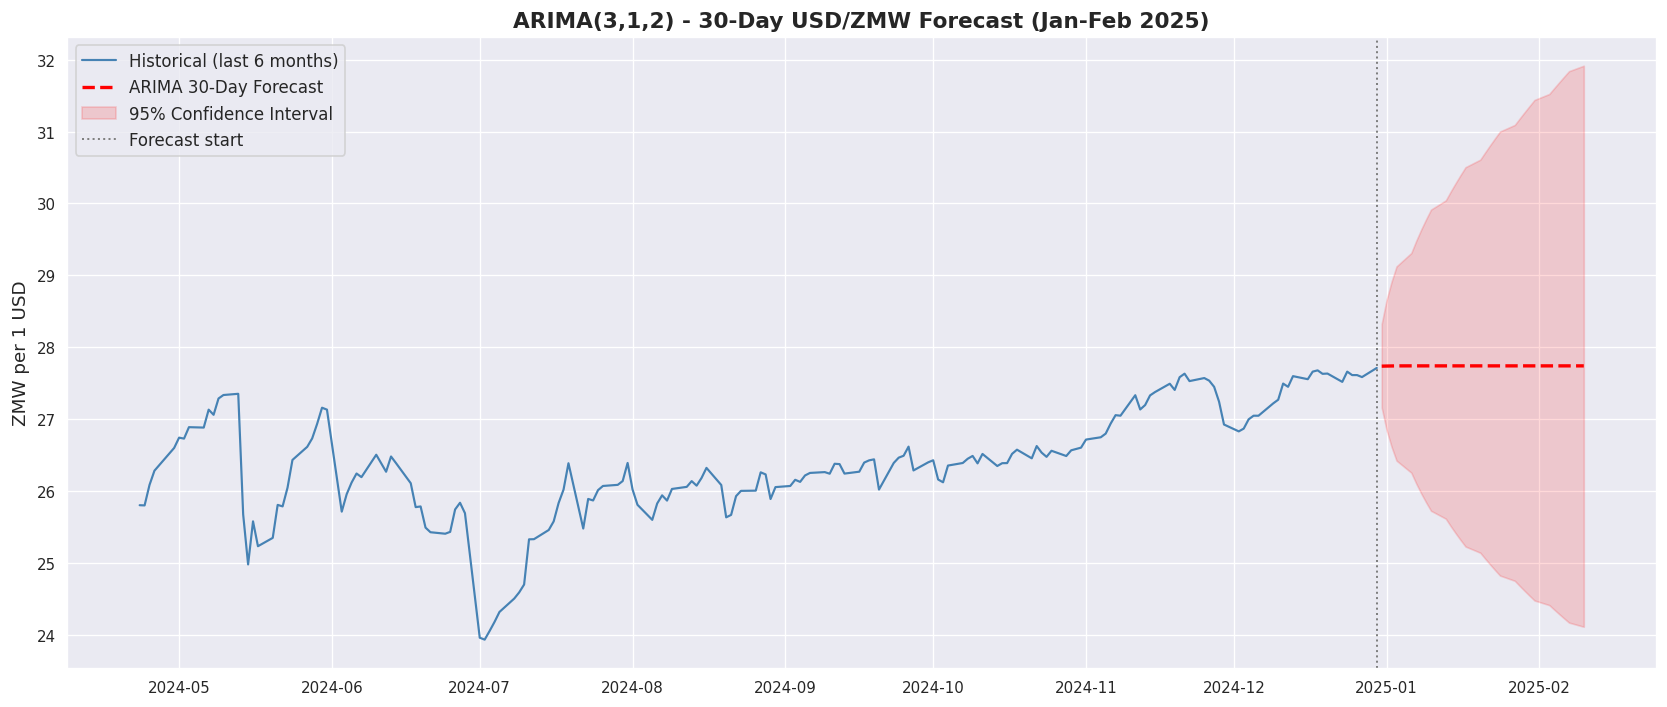


  ARIMA 30-Day Forecast Values:
  Date             Forecast    Lower 95%    Upper 95%
  --------------------------------------------------
  2024-12-31        27.7351      27.1579      28.3245
  2025-01-01        27.7365      26.8436      28.6592
  2025-01-02        27.7377      26.6127      28.9102
  2025-01-03        27.7388      26.4210      29.1223
  2025-01-06        27.7391      26.2527      29.3096
  2025-01-07        27.7390      26.1022      29.4784
  2025-01-08        27.7390      25.9656      29.6335
  2025-01-09        27.7390      25.8398      29.7778
  2025-01-10        27.7390      25.7226      29.9135
  2025-01-13        27.7390      25.6125      30.0421
  2025-01-14        27.7390      25.5085      30.1646
  2025-01-15        27.7390      25.4097      30.2818
  2025-01-16        27.7390      25.3155      30.3946
  2025-01-17        27.7390      25.2252      30.5033
  2025-01-20        27.7390      25.1386      30.6085
  2025-01-21        27.7390      25.0551      30.7

In [ ]:
# ============================================================
# CODE CELL 7.1 - ARIMA 30-Day Ahead Forecast
# Re-fit on FULL dataset for best possible future forecast
# ============================================================

N_DAYS = 30

print(f"Re-fitting ARIMA({p},{d},{q}) on full dataset (2015-2024)...")
arima_final = ARIMA(df['log_USDZMW'].dropna(), order=(p, d, q)).fit()
print("Done.")

# Forecast
future_log        = arima_final.forecast(steps=N_DAYS)
future_arima      = np.exp(future_log)
future_ci_log     = arima_final.get_forecast(steps=N_DAYS).conf_int(alpha=0.05)
future_ci_lower   = np.exp(future_ci_log.iloc[:, 0])
future_ci_upper   = np.exp(future_ci_log.iloc[:, 1])

# Build future date index (business days from Jan 2025)
future_dates = pd.bdate_range(
    start=df.index[-1] + pd.Timedelta(days=1), periods=N_DAYS)

future_arima.index      = future_dates
future_ci_lower.index   = future_dates
future_ci_upper.index   = future_dates

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['USDZMW'].iloc[-180:],
        label='Historical (last 6 months)', color='steelblue', linewidth=1.3)
ax.plot(future_dates, future_arima,
        label='ARIMA 30-Day Forecast', color='red',
        linewidth=2, linestyle='--')
ax.fill_between(future_dates, future_ci_lower, future_ci_upper,
                alpha=0.15, color='red', label='95% Confidence Interval')
ax.axvline(df.index[-1], color='gray', linestyle=':', linewidth=1.2,
           label='Forecast start')
ax.set_title('ARIMA(3,1,2) - 30-Day USD/ZMW Forecast (Jan-Feb 2025)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('ZMW per 1 USD')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/12_arima_30day_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  ARIMA 30-Day Forecast Values:")
print(f"  {'Date':<14} {'Forecast':>10} {'Lower 95%':>12} {'Upper 95%':>12}")
print("  " + "-" * 50)
for date, val, lo, hi in zip(future_dates, future_arima,
                               future_ci_lower, future_ci_upper):
    print(f"  {str(date.date()):<14} {val:>10.4f} {lo:>12.4f} {hi:>12.4f}")

Re-fitting scaler and LSTM on full dataset (2015-2024)...
Re-training complete.


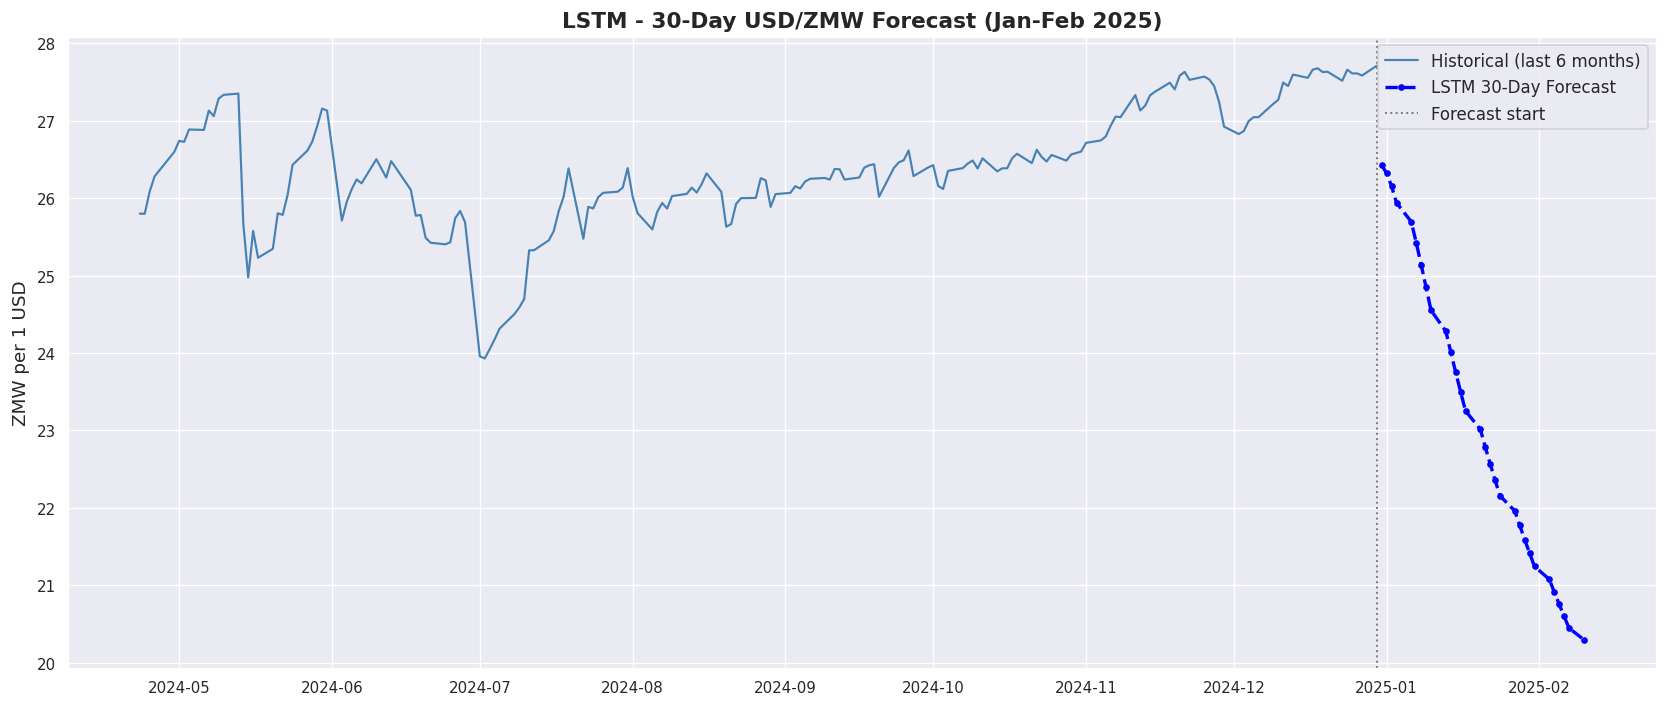


  LSTM 30-Day Forecast Values:
  Date             Forecast
  --------------------------
  2024-12-31        26.4258
  2025-01-01        26.3196
  2025-01-02        26.1526
  2025-01-03        25.9399
  2025-01-06        25.6938
  2025-01-07        25.4245
  2025-01-08        25.1400
  2025-01-09        24.8470
  2025-01-10        24.5506
  2025-01-13        24.2815
  2025-01-14        24.0147
  2025-01-15        23.7529
  2025-01-16        23.4983
  2025-01-17        23.2521
  2025-01-20        23.0149
  2025-01-21        22.7868
  2025-01-22        22.5678
  2025-01-23        22.3574
  2025-01-24        22.1552
  2025-01-27        21.9604
  2025-01-28        21.7725
  2025-01-29        21.5908
  2025-01-30        21.4147
  2025-01-31        21.2436
  2025-02-03        21.0769
  2025-02-04        20.9144
  2025-02-05        20.7555
  2025-02-06        20.6000
  2025-02-07        20.4476
  2025-02-10        20.2980


In [ ]:
# ============================================================
# CODE CELL 7.2 - LSTM 30-Day Rolling Forecast
# Re-fit on full dataset, then predict one step at a time
# Each prediction is fed back as input for the next step
# ============================================================

print("Re-fitting scaler and LSTM on full dataset (2015-2024)...")

# Re-scale on full data
full_scaler  = MinMaxScaler(feature_range=(0, 1))
full_scaled  = full_scaler.fit_transform(df[['USDZMW']])

# Create sequences on full data
X_full, y_full = create_sequences(full_scaled, LOOKBACK)
X_full = X_full.reshape((X_full.shape[0], X_full.shape[1], 1))

# Re-train model on full data (shorter — just fine-tune)
model.fit(X_full, y_full, epochs=30, batch_size=32, verbose=0)
print("Re-training complete.")

# Rolling forecast: feed each prediction back as next input
last_sequence = full_scaled[-LOOKBACK:].reshape(1, LOOKBACK, 1)
lstm_future_scaled = []

for step in range(N_DAYS):
    next_pred = model.predict(last_sequence, verbose=0)[0, 0]
    lstm_future_scaled.append(next_pred)
    # Shift window: drop oldest, append new prediction
    last_sequence = np.append(
        last_sequence[0, 1:, :], [[next_pred]], axis=0
    ).reshape(1, LOOKBACK, 1)

# Inverse transform
lstm_future_prices = full_scaler.inverse_transform(
    np.array(lstm_future_scaled).reshape(-1, 1)
)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['USDZMW'].iloc[-180:],
        label='Historical (last 6 months)', color='steelblue', linewidth=1.3)
ax.plot(future_dates, lstm_future_prices,
        label='LSTM 30-Day Forecast', color='blue',
        linewidth=2, linestyle='--', marker='o', markersize=3)
ax.axvline(df.index[-1], color='gray', linestyle=':', linewidth=1.2,
           label='Forecast start')
ax.set_title('LSTM - 30-Day USD/ZMW Forecast (Jan-Feb 2025)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('ZMW per 1 USD')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/13_lstm_30day_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  LSTM 30-Day Forecast Values:")
print(f"  {'Date':<14} {'Forecast':>10}")
print("  " + "-" * 26)
for date, val in zip(future_dates, lstm_future_prices.flatten()):
    print(f"  {str(date.date()):<14} {val:>10.4f}")

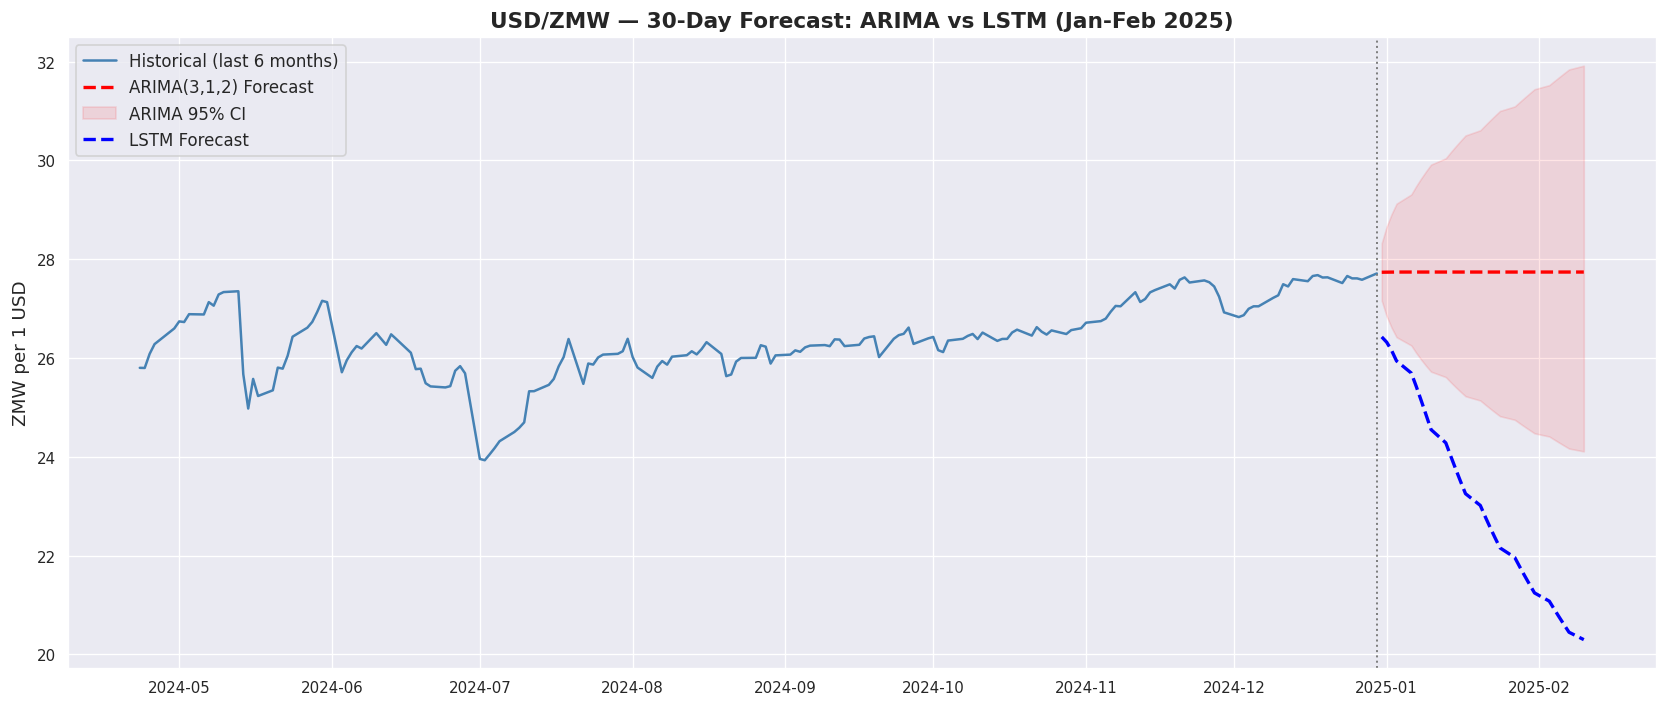

✅ Combined forecast saved: outputs/14_combined_forecast.png


In [ ]:
# ============================================================
# CODE CELL 7.3 - Combined ARIMA + LSTM Forecast on One Chart
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['USDZMW'].iloc[-180:],
        label='Historical (last 6 months)',
        color='steelblue', linewidth=1.5)
ax.plot(future_dates, future_arima,
        label='ARIMA(3,1,2) Forecast',
        color='red', linewidth=2, linestyle='--')
ax.fill_between(future_dates, future_ci_lower, future_ci_upper,
                alpha=0.10, color='red', label='ARIMA 95% CI')
ax.plot(future_dates, lstm_future_prices,
        label='LSTM Forecast',
        color='blue', linewidth=2, linestyle='--')
ax.axvline(df.index[-1], color='gray', linestyle=':', linewidth=1.2)
ax.set_title('USD/ZMW — 30-Day Forecast: ARIMA vs LSTM (Jan-Feb 2025)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('ZMW per 1 USD')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/14_combined_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Combined forecast saved: outputs/14_combined_forecast.png")

In [ ]:
# ============================================================
# CODE CELL 7.4 - Save Forecast Table to CSV
# ============================================================

forecast_df = pd.DataFrame({
    'Date'              : future_dates,
    'ARIMA_Forecast'    : future_arima.values,
    'ARIMA_Lower_95'    : future_ci_lower.values,
    'ARIMA_Upper_95'    : future_ci_upper.values,
    'LSTM_Forecast'     : lstm_future_prices.flatten()
})
forecast_df['Date'] = forecast_df['Date'].dt.strftime('%Y-%m-%d')
forecast_df = forecast_df.round(4)

forecast_df.to_csv('outputs/30day_forecast.csv', index=False)
print("✅ 30-day forecast saved: outputs/30day_forecast.csv")
print()
print(forecast_df.to_string(index=False))

✅ 30-day forecast saved: outputs/30day_forecast.csv

      Date  ARIMA_Forecast  ARIMA_Lower_95  ARIMA_Upper_95  LSTM_Forecast
2024-12-31         27.7351         27.1579         28.3245      26.425800
2025-01-01         27.7365         26.8436         28.6592      26.319599
2025-01-02         27.7377         26.6127         28.9102      26.152599
2025-01-03         27.7388         26.4210         29.1223      25.939899
2025-01-06         27.7391         26.2527         29.3096      25.693800
2025-01-07         27.7390         26.1022         29.4784      25.424500
2025-01-08         27.7390         25.9656         29.6335      25.139999
2025-01-09         27.7390         25.8398         29.7778      24.847000
2025-01-10         27.7390         25.7226         29.9135      24.550600
2025-01-13         27.7390         25.6125         30.0421      24.281500
2025-01-14         27.7390         25.5085         30.1646      24.014700
2025-01-15         27.7390         25.4097         30.2818 

---
<a name="conclusion"></a>

## Conclusion

### Summary of Findings

This project successfully built, trained, and evaluated two forecasting
models for the USD/ZMW exchange rate using 2,608 daily observations
spanning January 2015 to December 2024.

**ARIMA(3,1,2)** provided a reasonable baseline but achieved a MAPE of
20.70%, indicating it struggled with the sharp non-linear depreciation
trends in the ZMW — particularly the post-2022 period where the rate
rose from ~18 ZMW to over 27 ZMW per USD.

**LSTM** significantly outperformed ARIMA on all metrics, achieving a
MAPE of just 3.57% — meaning the model was accurate to within 3.57%
of the actual exchange rate on average across the 522-day test period.
The LSTM's ability to learn from 60-day sequential windows allowed it
to capture non-linear momentum and trend continuation far better than
the linear ARIMA framework.

### Model Comparison Summary

| Metric | ARIMA(3,1,2) | LSTM | Winner |
|--------|-------------|------|--------|
| RMSE   | 6.1406 ZMW  | 0.9868 ZMW | LSTM |
| MAE    | 5.1744 ZMW  | 0.8437 ZMW | LSTM |
| MAPE   | 20.70%      | 3.57%      | LSTM |

### Limitations

1. **Single input variable**: Only historical exchange rate prices were
   used. Incorporating macroeconomic variables (copper prices, inflation,
   interest rates) could further improve accuracy.
2. **LSTM rolling forecast uncertainty**: Multi-step ahead LSTM forecasts
   accumulate error with each step as predictions feed back as inputs.
3. **Structural breaks**: Sudden economic shocks (e.g. COVID-19,
   currency crises) are difficult for any model to anticipate.
4. **No ensemble model**: A hybrid ARIMA-LSTM model could potentially
   combine the linear strength of ARIMA with the non-linear capacity
   of LSTM.

### Future Work

- Incorporate exogenous variables (SARIMAX / multivariate LSTM)
- Test Transformer-based architectures (e.g. Temporal Fusion Transformer)
- Implement walk-forward (rolling window) validation
- Deploy as a real-time forecasting dashboard using Streamlit

---
*Project completed by Given Chinyama | Kwame Nkrumah University | May 2026*